<a href="https://colab.research.google.com/github/Bela1810/SleepHealth-Analytics/blob/main/Proyecto_CD_2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="font-family: Arial;">
<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">
<h3 style="text-align: center;">
<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INGELIGENCIA ARTIFICIAL</b>
</h3>
<h3 style="text-align: center; color:  #C2262B;"> <!--Color institucional-->
<strong>Introducción a la Ciencia de Datos - Proyecto de Aula<strong>
</h3>
<h3>
<b>Integrantes:</b>
<p>Juan Camilo Manjares<p>
<p>Isabella Montoya Castellanos<p>
<p>Daniel Ospina<p>
</h3>
<hr style="width:100%; border:1px solid withe;">
<h6 style="text-align: rigth; margin-bottom: 5px">
<b>SEMESTRE 2026-1<b>
</h6>
</div>

#**Librerias**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, chi2_contingency, kstest
import statsmodels.api as sm


import scipy.stats as st
import statsmodels.api as sm
import statsmodels.stats.api as sms # otra api donde esta el test de Linealidad y Homosecdasticidad
from sklearn.model_selection import train_test_split # Para dividir al conjunto en entrenamiento y prueba
                  # La librería Scikit-Learn sirve para realizar tareas de aprendizaje automático, ofreciendo una interfaz estandarizada y eficiente
                  # para implementar algoritmos de clasificación, regresión, clustering (agrupamiento) y reducción de dimensionalidad.
from sklearn.preprocessing import StandardScaler # Para estandarizar variables (media 0 y sigma 1)
from statsmodels.stats.outliers_influence import variance_inflation_factor # Para calcular los VIF's (multicolinealidad)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Medidas de calidad de ajuste MAE, MSE, R^2
from statsmodels.stats.diagnostic import linear_reset # Prueba de Ramsey RESET (especificación del modelo - linealidad)
from statsmodels.stats.stattools import durbin_watson # Test de Durbin-Watson (Independencia)
from statsmodels.stats.diagnostic import het_breuschpagan # Test de Breusch-Pagan (Homocedasticidad)
from sklearn.preprocessing import MinMaxScaler
import statsmodels.tsa.api as tsa # Módulo específico para series de tiempo
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Para dibujar el correlograma ACF (total) y el PACF (parcial)
sns.set()

In [ ]:
#Mount and connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/bdsel.csv' #Ruta Daniel

In [ ]:
file_path = '/content/sleep_health_dataset.csv'   #ruta Bela

# **CONJUNTO DE DATOS - Salud del sueño y Rendimiento diario**

## **Contexto**

▻  **Descripción General**

Este dataset está publicado en Kaggle por el usuario Mohan Krishna Thalla (autor del dataset en Kaggle).

https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/data

---

Este conjunto de datos contiene 100.000 registros sintéticos de pacientes, diseñados para un análisis exhaustivo de la salud del sueño, la predicción del riesgo de trastornos y la modelización del rendimiento cognitivo.

Cada registro captura una instantánea diaria completa: mediciones de la arquitectura del sueño, hábitos de vida, estado psicológico y resultados cognitivos del día siguiente.

Según la descripción del propio dataset, no es un dataset “crudo” levantado directamente de un estudio o encuesta única, sino un dataset sintético: sus distribuciones y correlaciones fueron calibradas usando fuentes y estudios poblacionales revisados por pares, y menciona como referencias (a nivel de calibración) encuestas/estudios como CDC National Health Interview Survey (2024), Sleep Foundation population studies, Frontiers in Sleep (2025) y Framingham Heart Study.

En otras palabras: quien lo construye o recolecta como archivo final es el autor del conjunto de datos, y el “origen” de la estructura estadística está inspirado/calibrado con fuentes de salud pública, pero no corresponde a mediciones de personas reales identificables con un levantamiento único.

▻  **Situación problema que plantea**

La situación problema que habilita este conjunto de datos es analizar cómo se relacionan:

los hábitos de sueño (duración, calidad, horarios/consistencia, etc.),
el estado de salud (indicadores fisiológicos y/o riesgo),
y el desempeño diario (productividad, rendimiento, fatiga, etc.)
con el objetivo de:

* Entender patrones (por ocupación, edad, estilo de vida)

* Detectar factores de riesgo asociados a peor descanso o menor desempeño

* Predecir variables objetivo relacionadas con rendimiento/salud a partir de hábitos diarios.



▻  **Qué información contiene**

A nivel general, el dataset está diseñado con variables que suelen agruparse en:

* **Perfil sociodemográfico y contexto:** Que contiene variables como el id de la persona, edad, género, BMI, pais y ocupación. Este grupo de columnas con el proposito de quién es la persona.

* **Métricas de sueño:** Contiene variables relacionadas con duración y calidad del sueño, tanto en puntaje como porcentaje y otros componentes del comportamiento de descanso. Con la finalidad de saber como duermen estás personas.

* **Estilo de Vida:** Contiene variables de su consumo de cafeina o alcohol, su tiempo en pantalla o si hacen ejercicio o toman siesta. Para saber lo que hacen en su vida diaria.

* **Detalle psicologico:** Contiene variables donde se puntúa su estres, sus horas de trabajo o el estado de su salud mental. Para medir como se sienten.


* **Salud y fisiología:** Indicadores que capturan estado de salud (por ejemplo, métricas fisiológicas y categorías de condición corporal o salud cardiaca).




## **Variables**

| #  | Variable                      | Tipo / Categoría             | Descripción                               |
| -- | ----------------------------- | ---------------------------- | ----------------------------------------- |
| 1  | `person_id`                   | Numérica (discreta)          | Identificador único del individuo         |
| 2  | `age`                         | Numérica (discreta)          | Edad del individuo                        |
| 3  | `gender`                      | Categórica (Male/Female)     | Género del individuo                      |
| 4  | `occupation`                  | Categórica                   | Profesión u ocupación                     |
| 5  | `bmi`                         | Numérica continua            | Índice de masa corporal                   |
| 6  | `country`                     | Categórica                   | País de origen                            |
| 7  | `sleep_duration_hrs`          | Numérica continua (horas)    | Horas de sueño por noche                  |
| 8  | `sleep_quality_score`         | Numérica continua            | Calidad del sueño percibida               |
| 9  | `rem_percentage`              | Numérica continua (%)        | Porcentaje de sueño REM                   |
| 10 | `deep_sleep_percentage`       | Numérica continua (%)        | Porcentaje de sueño profundo              |
| 11 | `sleep_latency_mins`          | Numérica continua (min)      | Tiempo para quedarse dormido              |
| 12 | `wake_episodes_per_night`     | Numérica discreta            | Número de despertares nocturnos           |
| 13 | `caffeine_mg_before_bed`      | Numérica continua (mg)       | Cafeína consumida antes de dormir         |
| 14 | `alcohol_units_before_bed`    | Numérica continua            | Alcohol consumido antes de dormir         |
| 15 | `screen_time_before_bed_mins` | Numérica continua (min)      | Tiempo en pantallas antes de dormir       |
| 16 | `exercise_day`                | Binaria (0/1)                | Si hizo ejercicio ese día                 |
| 17 | `steps_that_day`              | Numérica discreta            | Número de pasos diarios                   |
| 18 | `nap_duration_mins`           | Numérica continua (min)      | Duración de siesta                        |
| 19 | `stress_score`                | Numérica continua            | Nivel de estrés                           |
| 20 | `work_hours_that_day`         | Numérica continua (horas)    | Horas trabajadas ese día                  |
| 21 | `chronotype`                  | Categórica                   | Ritmo biológico (Morning/Evening/Neutral) |
| 22 | `mental_health_condition`     | Categórica                   | Condición de salud mental                 |
| 23 | `heart_rate_resting_bpm`      | Numérica continua (bpm)      | Frecuencia cardíaca en reposo             |
| 24 | `sleep_aid_used`              | Binaria (0/1)                | Uso de ayuda para dormir                  |
| 25 | `shift_work`                  | Binaria (0/1)                | Trabajo por turnos                        |
| 26 | `room_temperature_celsius`    | Numérica continua (°C)       | Temperatura de la habitación              |
| 27 | `weekend_sleep_diff_hrs`      | Numérica continua (horas)    | Diferencia de sueño en fin de semana      |
| 28 | `season`                      | Categórica                   | Estación del año                          |
| 29 | `day_type`                    | Categórica (Weekday/Weekend) | Tipo de día                               |
| 30 | `cognitive_performance_score` | Numérica continua            | Rendimiento cognitivo (0-100)                   |
| 31 | `sleep_disorder_risk`         | Categórica                   | Riesgo de trastorno del sueño             |
| 32 | `felt_rested`                 | Binaria (0/1)                | Si se sintió descansado                   |





#**Carga de Datos**

In [ ]:
df = pd.read_csv(file_path)

df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

#**ANALISIS EXPLORATORIO DE DATOS (EDA)**

## **Tratamiento Preliminar**

El dataset seleccionado no requiere un tratamiento preliminar significativo, debido a su naturaleza sintética y a la forma en que fue diseñado.

Al haber sido construido por un autor a partir de datos estadisticos basados en estudios poblacionales confiables, presenta una estructura organizada, coherente y lista para su análisis.

Durante la revisión inicial de los datos, no se identificaron valores nulos, registros incompletos ni inconsistencias en las variables, lo que evita la necesidad de aplicar técnicas de limpieza como imputación de datos, eliminación de observaciones o corrección de errores.

Las variables se encuentran correctamente definidas, facilitando su manipulación y análisis.

En este sentido, el dataset permite avanzar directamente hacia el análisis descriptivo y exploratorio de datos.

## **Descripción de los Datos**

▻  **Objetivo y propósito del análisis descriptivo**

El objetivo del presente análisis es describir el comportamiento de las variables relacionadas con el sueño, el estilo de vida y el estado fisiológico de los individuos, con el fin de identificar patrones, tendencias y posibles relaciones con el rendimiento cognitivo medido a través de la variable **cognitive_performance_score**.

Se busca comprender cómo factores como la duración del sueño, la eficiencia del descanso, el nivel de estrés y los hábitos diarios influyen en el desempeño cognitivo, proporcionando una base sólida para la construcción de modelos predictivos.



▻  **Preguntas Motivacionales**


* ¿Cómo se distribuye el rendimiento cognitivo en la población analizada?

* ¿Cuál es el comportamiento de las variables relacionadas con el sueño (duración, eficiencia, fases del sueño)?

* ¿Qué variables presentan mayor correlación con el rendimiento cognitivo?

* ¿Realmente las personas que usan ayuda para dormir se sienten más descansadas?

In [ ]:
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


▻ **Observaciones:**

**Para las variables relacionadas con la población**:

* Para `age` promedio de las personas es de 34.7 años, con un rango entre 18 y 69 años, lo que indica una población mayormente es adulta. Hay cercania en la media y la mediana por lo que la distribución es proxima a ser simetrica.

* Para `BMI` presenta una media de 26.28, que se ubica por encima del rango normal:

El BMI categorías estándar:

- Bajo peso: < 18.5
- Normal: 18.5 – 24.9
- Sobrepeso: 25 – 29.9
- Obesidad: ≥ 30

Por lo tanto hay tendencia hacia sobrepeso en la población.

También la media y la mediana son muy cercanas, por lo tanto también se aproxima a ser una distribución simetrica.

**Para las variables relacionadas con el sueño**:

* Para `sleep_duration_hrs` La duración promedio del sueño es de 6.42 horas, lo que es menos a las 7–8 horas recomendadas que una persona debe dormir. La media y la mediana son muy cercanas lo que indica que se aproxima a una distribución simetrica, aunque el rango este entre 3 y 10 horas, se llega a evidenciar posibles valores extremos.

* Para `sleep_quality_score` La calidad del sueño tiene una media de 4.87 sobre el maximo que es 10, lo que indica un valor bajo indicando que la calidad del sueño no es tan optima.

* Para `rem_percentage` y `deep_sleep_percentage`las medias y medianas son muy parecidas por lo que la distribución es simetrica sin valores atipicos.

* Para `sleep_latency_mins` presenta una media 19.8 ligeramente mayor a la mediana 19, lo que significa que hay asimetría positiva, indicando que algunas personas tardan mucho más en dormir.

* Para `wake_episodes_per_night` también se visualiza una asimetria positiva ya que su media 3.34 es mayor a la mediana 3. Hay altos valores que aumentan la media

**Para las variables de estilo de vida y habitos**:

* Para `caffeine_mg_before_bed`, el consumo de cafeína antes de dormir tiene una media de 38.8 lo cual es mayor a la mediana (0), hay una fuerte asimetría positiva lo cual indica que la mayoria no consume cafeína antes de dormir, pero algunos valores altos elevan el promedio, pueden haber posibles outliers ya que hay un maximo de 400 lo cuál es un número muy alto.

* Para `nap_duration_mins` se observa el mismo comportamiento, una fuerte asimetría positiva y una posible presencia de outliers.

* Para `stress_score`: El nivel de estrés promedio es de 5.73 (escala 1–10), lo que indica un nivel moderado y su media y mediana son similares por lo que es una distribución simetrica sin valores atípicos.

* Para `work_hours_that_day`. Las horas de trabajo diarias tienen una media de 7.13 horas, con valores máximos de hasta 18 horas. Esto puede indicar que hay presencia de outliers ya que son jornadas de trabajo muy extensas.

* Para `cognitive_performance_score`, la media (59.22) es menor que la mediana (60.4), lo que da presencia de una asimetría negativa, indicando que existen valores bajos que afectan el promedio.

* Para `felt_rested`, la mediana es 0, lo cual confirma que  al menos la mitad de todos los registros respondió que no se siente descansada.


### **Revisión de Datos Ausentes**

In [ ]:
df.isnull().sum()
(df.isnull().mean() * 100).round(2)

,0
person_id,0.0
age,0.0
gender,0.0
occupation,0.0
bmi,0.0
country,0.0
sleep_duration_hrs,0.0
sleep_quality_score,0.0
rem_percentage,0.0
deep_sleep_percentage,0.0


▻ **Observación:** Al revisar el porcentaje de datos ausentes por variables, se puede concluir que ninguna variable no presenta valores ausentes.

Lo cual representa una ventaja significativa para el análisis.

Esto implica que:

* No es necesario aplicar técnicas de imputación con media o mediana.
* No se requiere eliminar registros, lo cual evita la pérdida de información.


### **Graficos**

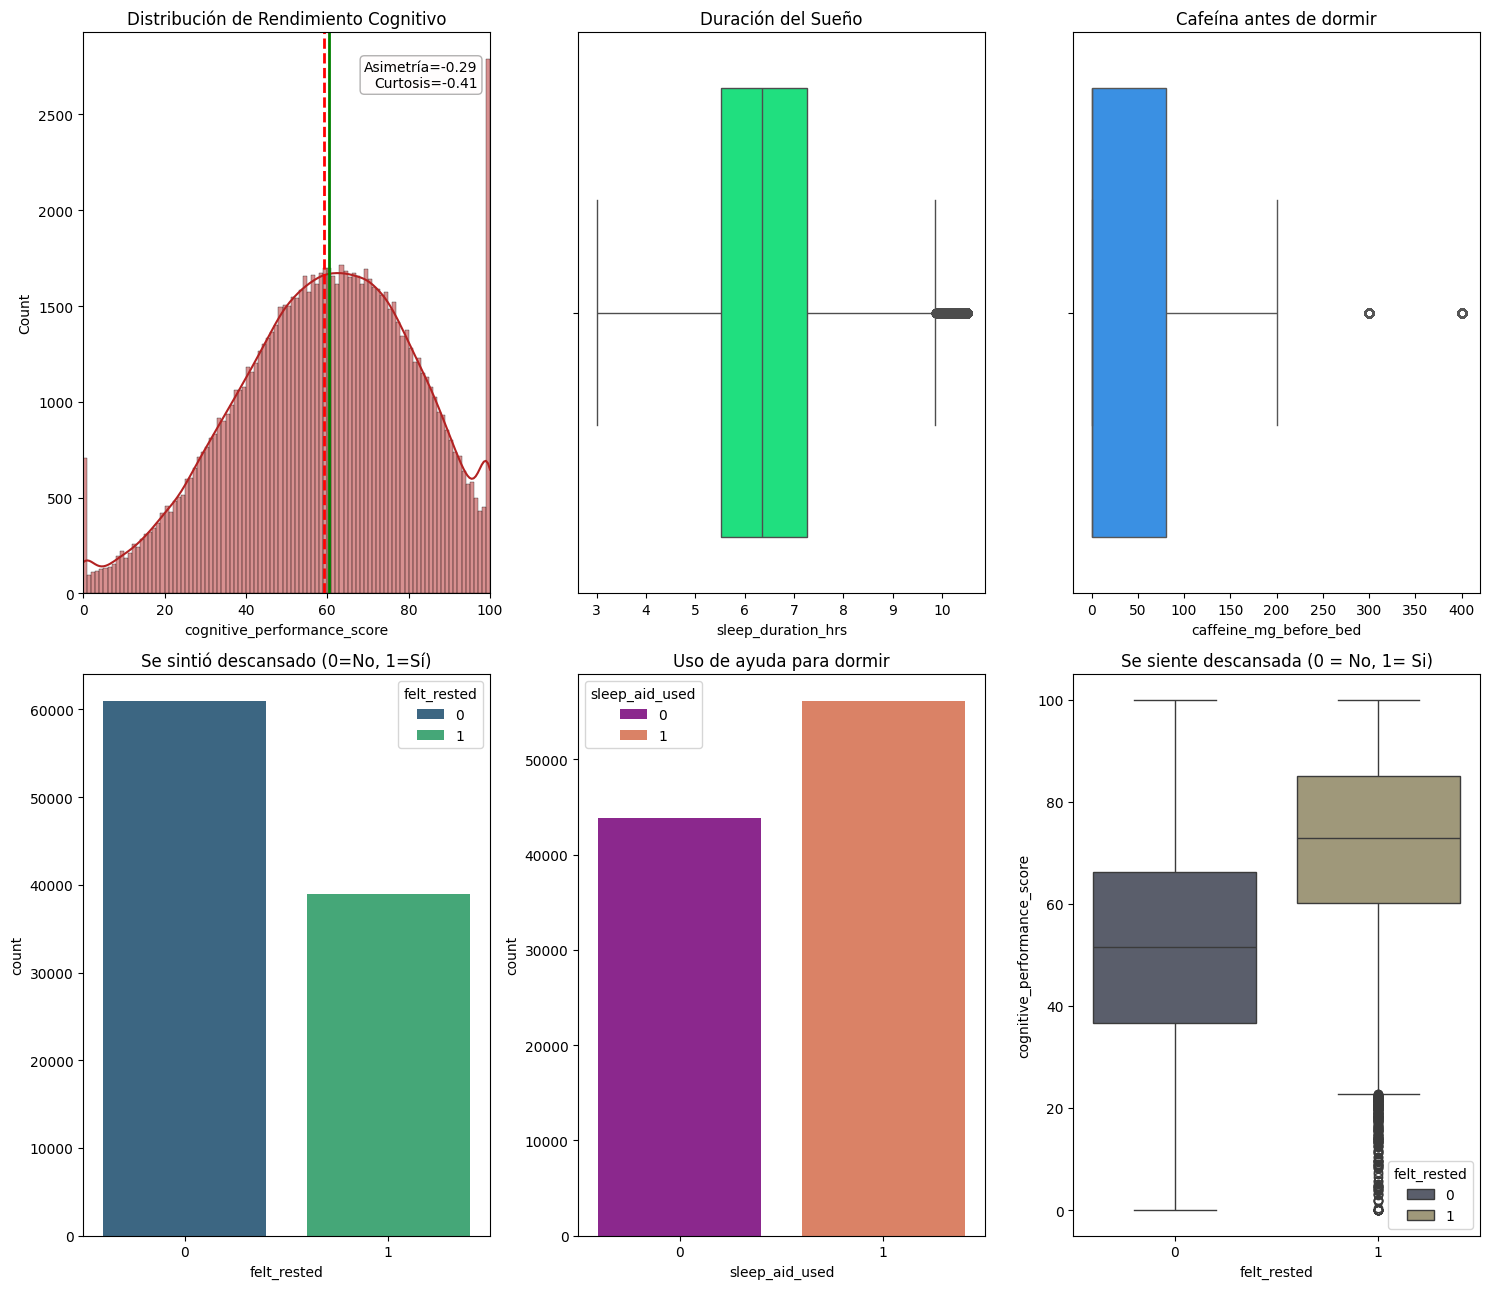

In [ ]:
fig, eje = plt.subplots(2, 3, figsize=(15,13))

sns.histplot(df['cognitive_performance_score'], bins=100, kde=True, ax=eje[0,0], color="firebrick")
eje[0,0].set_xlim(0, 100)
eje[0,0].set_title("Distribución de Rendimiento Cognitivo")

asimetria = skew(df['cognitive_performance_score'])
curt = kurtosis(df['cognitive_performance_score'])
curt_total = kurtosis(df['cognitive_performance_score'], fisher=False)

media = df['cognitive_performance_score'].mean()
mediana = df['cognitive_performance_score'].median()

eje[0,0].axvline(media, color='red', linestyle='--', linewidth=2)
eje[0,0].axvline(mediana, color='green', linestyle='-', linewidth=2)

eje[0,0].text(0.97, 0.95, f"Asimetría={asimetria:.2f}\nCurtosis={curt:.2f}", transform=eje[0,0].transAxes, ha='right', va='top',
              bbox=dict(boxstyle='round', facecolor='snow', alpha=0.3))

sns.boxplot(x='sleep_duration_hrs',data=df, ax=eje[0,1], color="springgreen")
eje[0,1].set_title("Duración del Sueño")

sns.boxplot(x=df['caffeine_mg_before_bed'], ax=eje[0,2], color="dodgerblue")
eje[0,2].set_title("Cafeína antes de dormir")

sns.countplot(x='felt_rested', data=df, ax=eje[1,0],  hue='felt_rested' , palette='viridis')
eje[1,0].set_title("Se sintió descansado (0=No, 1=Sí)")

sns.countplot(x='sleep_aid_used', data=df, ax=eje[1,1], hue='sleep_aid_used', palette="plasma")
eje[1,1].set_title("Uso de ayuda para dormir")

sns.boxplot(x='felt_rested',y='cognitive_performance_score',data=df, ax=eje[1,2],hue='felt_rested', palette="cividis")
eje[1,2].set_title("Se siente descansada (0 = No, 1= Si)")

plt.tight_layout()
plt.show()

▻ **Observaciones:** Con estas gráficas preliminares se obtiene una visualización del comportamiento del rendimiento cognitivo.

1. **Distribución de Rendimiento Cognitivo**


    En el caso de la distribución del rendimiento cognitivo, el coeficiente de asimetría presenta un valor de -0.29, lo que indica una asimetría negativa leve, donde la cola de la distribución se extiende hacia la izquierda.

    Aunque la mayoría de los registros se concentran alrededor de valores cercanos a 60, la distribución no es perfectamente simétrica debido a esta pequeña inclinación y a la acumulación de observaciones en el valor máximo (100), es decir, hay muchos datos que se acumulan en el valor maximo.


2. **Duración del Sueño**

    La mayoría de las personas duermen entre 6 y 7 horas, aunque hay presencia de valores atípicos para las personas que duermen más de 10 horas.

3. **Cafeína antes de dormir**

    La gran mayoría de personas consume muy poca cafeína antes de irse a dormir. Sin embargo se puede visualizar que hay valores atípicos muy extremos donde una persona consume hasta 400 mg de café lo cuál es mucho para irse a dormir.

4. **Descansadas**

    Según la grafica se puede evidenciar que más de 60.000 personas no se sienten descansadas, por cual se puede concluir que la gran mayoría no se siente descansada.

5. **Uso de medicamentos para dormir**

    Según la grafica se puede concluir que la gran mayoría de las personas con un valor mayor a 50.000 toman medicamentos que los ayuda a dormir.

6. **Analisis de Rendimiento Cognitivo con Sentirse Descansado**

    Con este grafico se puede confirmar que sentirse descansado eleva el rendimiento cognitivo, ya que esta caja se encuentra más arriba, también se pueden visualizar algunos valores atípicos.



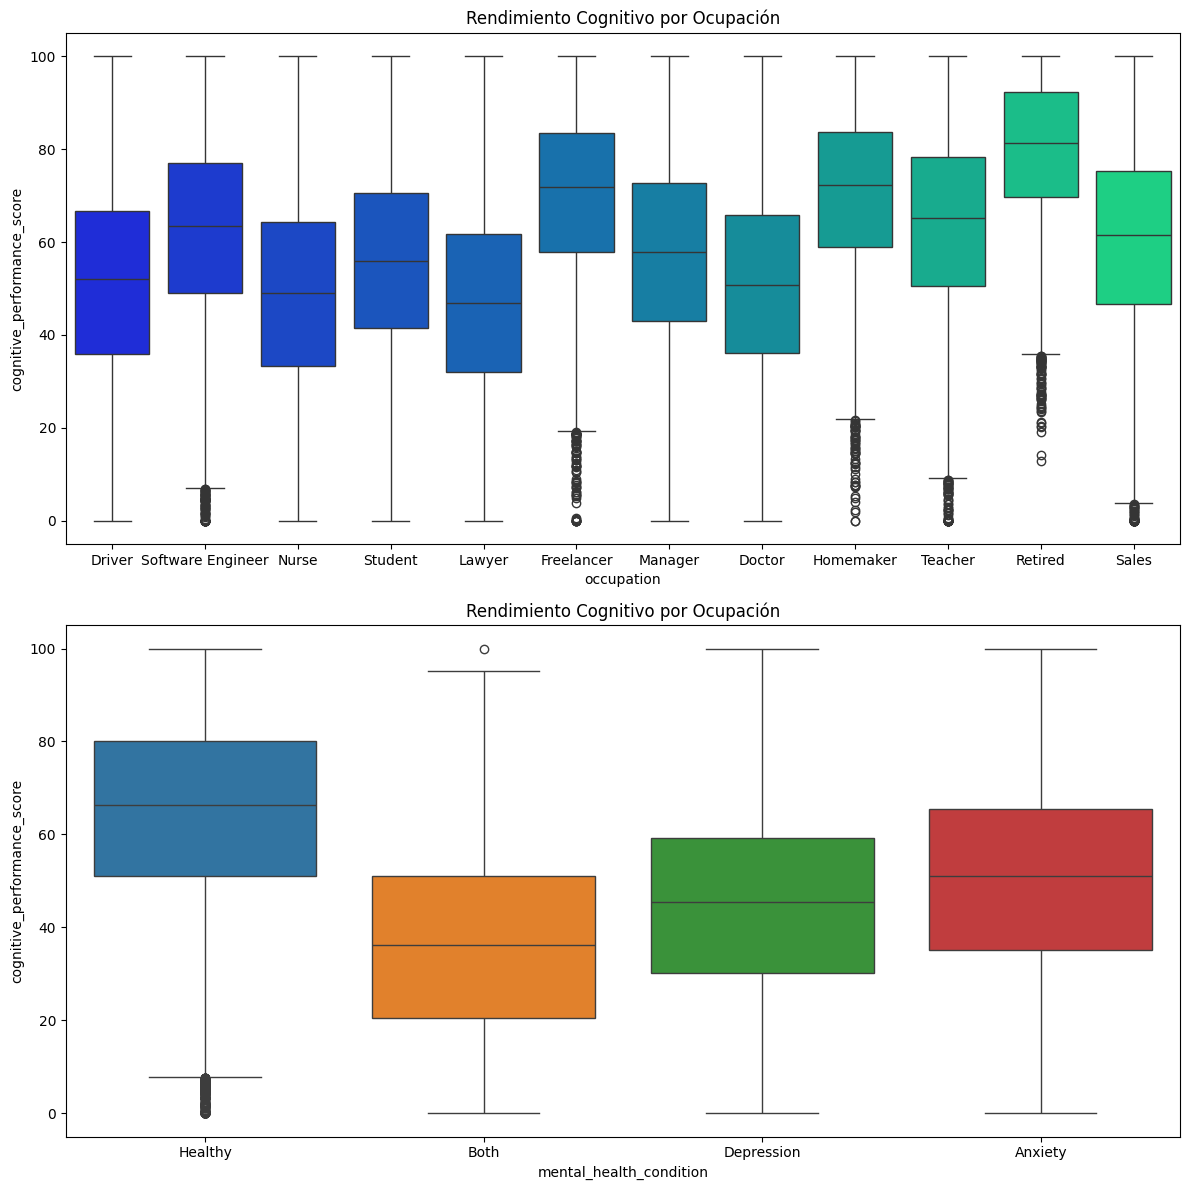

In [ ]:
fig, eje = plt.subplots(2, 1, figsize=(12,12))

sns.boxplot(x='occupation',y='cognitive_performance_score',data=df, ax=eje[0],hue='occupation', palette="winter")
eje[0].set_title("Rendimiento Cognitivo por Ocupación")

sns.boxplot(x='mental_health_condition',y='cognitive_performance_score',data=df, ax=eje[1],hue='mental_health_condition')
eje[1].set_title("Rendimiento Cognitivo por Ocupación")

plt.tight_layout()
plt.show()


▻ **Observaciones:**

1. **Rendimiento Cognitivo por Ocupación**


    Los de mayor rendimiento son los "Retired" (Jubilados) ya que presentan la mediana de rendimiento más alta, seguidos por Freelancers ( autónomos) y Homemakers (amas de casa).
    
    En este caso se puede concluir que los trabajos o cargos con menos estrés tienen mayor rendimiento cognitivo.

    Los de menor rendimiento son los profesiones como Lawyer (abogados), Nurse (enfermeros) y Sales (vendedores), estos muestran medianas más bajas y cajas muy amplias. Esto indica que estas áreas son las más afectadas en rendimiento cognitivo por no descansar bien.

    En este caso también se evidencia que algunas profesiones contienen valores atípicos.

1. **Estado de Salud Mental**

    * Realizando la grafica de cajas,podemos concluir que las personas más sanas son las que presentan un rendimiento cognitivo alto.

### **Tablas de Frecuencia y Contingencia**

▻ **Tabla de Frecuencia**

In [ ]:
tabla_frecuencias = df['mental_health_condition'].value_counts().head(10).reset_index()
tabla_frecuencias.columns = ['Estado Salud Mental', 'Frecuencia']

print(tabla_frecuencias)

  Estado Salud Mental  Frecuencia
0             Healthy       69993
1             Anxiety       15134
2          Depression        9854
3                Both        5019


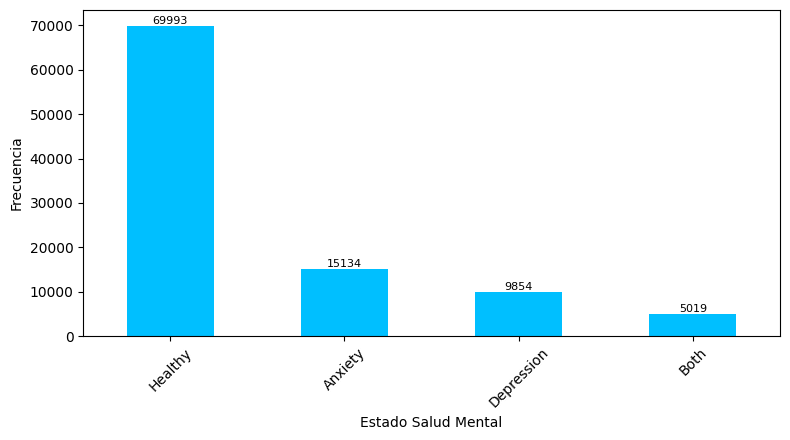

In [ ]:
ax = tabla_frecuencias.plot(
    kind='bar',
    x='Estado Salud Mental',
    y='Frecuencia',
    figsize=(8,4.5),
    color='deepskyblue',
    legend=False
)

plt.title("")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)


for contenedor in ax.containers:
    ax.bar_label(contenedor, fontsize=8)

plt.tight_layout()
plt.show()

▻ **Observación:**

Con 69,993 personas, la categoría dominante es Healthy (Saludable).

Después de las personas sanas se puede observar  el siguiente orden de frecuencia:

* Anxiety (Ansiedad): Es la condición más común con 15,134 casos.

* Depression (Depresión): Ocupa el tercer lugar con 9,854 casos.

* Both (Ambas): Es la menos frecuente con 5,019 casos, ya que representa a personas que sufren ambas condiciones de salud mental.

Hay  más personas saludables que personas con ansiedad y depresión juntas.

Si se entrena un modelo de sin ajustar este desbalance de clases, el modelo será muy bueno prediciendo a personas  sanas, pero podría tener dificultades para identificar correctamente a quienes tienen condiciones de salud mental.

▻ **Tabla de Contingencia**

In [ ]:
tabla_descanso = pd.crosstab(
    index=df["sleep_aid_used"],
    columns=df["felt_rested"],
    normalize="index")

tabla_descanso = tabla_descanso.round(2)
tabla_descanso.index = ['No usa ayuda para dormir', 'Usa ayuda para dormir']
tabla_descanso.columns = ['No descansado', 'Descansado']

print(tabla_descanso)

                          No descansado  Descansado
No usa ayuda para dormir           0.63        0.37
Usa ayuda para dormir              0.59        0.41


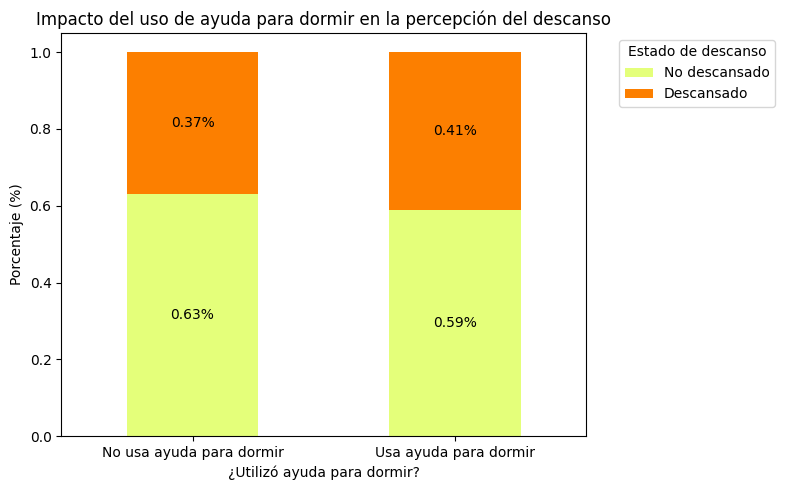

In [ ]:
ax = tabla_descanso.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    colormap="Wistia"
)

plt.title("Impacto del uso de ayuda para dormir en la percepción del descanso")
plt.ylabel("Porcentaje (%)")
plt.xlabel("¿Utilizó ayuda para dormir?")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", label_type="center", fontsize=10)

plt.legend(title="Estado de descanso", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

▻ **Observación:**

Al analizar los datos, se nota que usar ayuda para dormir solo mejora el descanso de forma muy leve. Mientras que el 37% de las personas que no usan nada se sienten descansadas, este número sube apenas al 41% en quienes sí usan ayuda. Por el contrario, el 63% de los que no usan nada y casi el 60% de los que sí usan ayuda reportan no sentirse descansados. Esto nos indica que, en esta población, tomar algo para dormir no garantiza un mejor descanso.

#**MODELO REGRESIÓN LINEAL MÚLTIPLE**

##**Variable Objetivo**

▻ **Explicación y Objetivo**

La variable objetivo seleccionada es `cognitive_performance_score`, la cual representa el nivel de rendimiento cognitivo de las personas en una escala de 0 a 100.

Esta variable fue escogida como objetivo porque:

* Es una variable cuantitativa continua, por lo que se puede utilizar sin problema en un modelo de regresión lineal múltiple.

* Nuestro objetivo en el análisis después de revisar el dataset y sus variables, es predecir el desempeño de las personas y entender cómo factores relacionados con la salud mental y el cuidado diario pueden influir en este.

* Esta variable reúne aspectos relacionados con el sueño, el estilo de vida y el estado mental, por lo que resulta adecuada para cumplir con el objetivo del análisis.

In [ ]:
#Estadisticos Basicos

df['cognitive_performance_score'].describe()

,cognitive_performance_score
count,100000.000000
mean,59.227295
std,22.249665
min,0.000000
25%,44.200000
50%,60.400000
75%,75.800000
max,100.000000


▻ **Observaciones:**

* La variable se encuentra dentro del rango esperado (0-100)

* En este caso la media (59.23) es menor a la mediana (60.40) , por lo tanto podríamos estar hablando de una asimetría negativa pero muy leve. Esto indica que los valores más bajos, la mayoría se extienden a la izquierda.




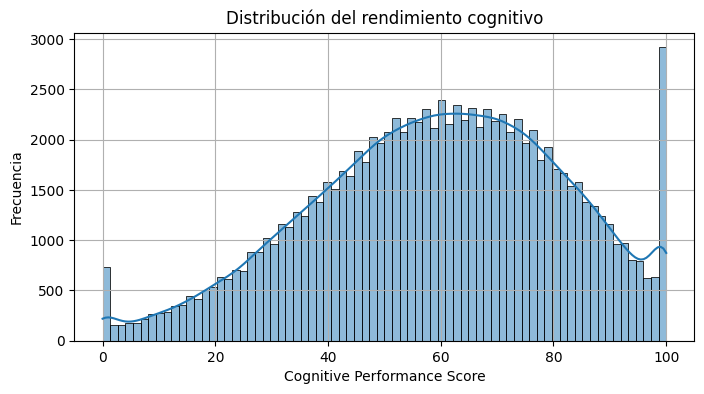

In [ ]:
#Histograma

plt.figure(figsize=(8,4))
sns.histplot(df['cognitive_performance_score'], kde=True)
plt.title('Distribución del rendimiento cognitivo')
plt.xlabel('Cognitive Performance Score')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

In [ ]:
skewness = df['cognitive_performance_score'].skew()
kurtosis = df['cognitive_performance_score'].kurt()

print("Asimetría (Skewness):", skewness)
print("Curtosis:", kurtosis)

Asimetría (Skewness): -0.2898818454916531
Curtosis: -0.41265524622937066


▻ **Observación:**

Con la visualización anteriormente creada de la distribución de la variable, se puede confirmar que hay presencia de una asimetría negativa. También se puede confirmar esto con los resultados en la Skewness (-0.29), la cual es una asimetría negativa y como es leve, se puede aproximar a una simetrica; En el caso de la Curtosis (-0.41), no hay picos extremos y es tipo campana.

Otra observación que se puede ver es que hay muchos registros con el valor máximo (100), lo que genera una concentración alta en ese punto. Entonces no hay tanta dispersión en esa zona, todos los valores que están en esa zona son casi iguales y puede reducir la variabilidad de los valores más altos.


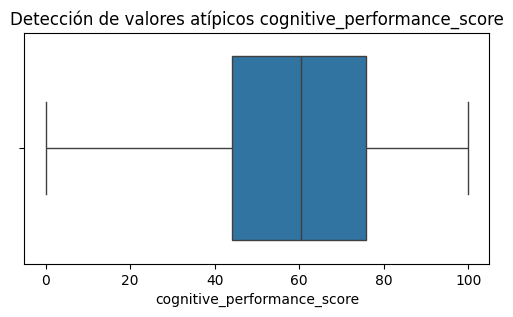

In [ ]:
#Analisis de Outliers

plt.figure(figsize=(6,3))
sns.boxplot(x=df['cognitive_performance_score'])
plt.title('Detección de valores atípicos cognitive_performance_score')
plt.show()

▻ **Observación:**

A partir del diagrama de caja, no se evidencian valores atípicos en la variable `cognitive_performance_score`, ya que no se observan datos fuera de los límites de los bigotes. Esto indica que la variable no presenta valores extremos que puedan afectar negativamente el análisis.

El valor central del rendimiento cognitivo se sitúa alrededor de 60.4, lo que indica que la mitad de los individuos presenta un desempeño inferior a ese valor.

##**ASOCIACIONES**

###**Relaciones bivariadas entre variables numéricas**

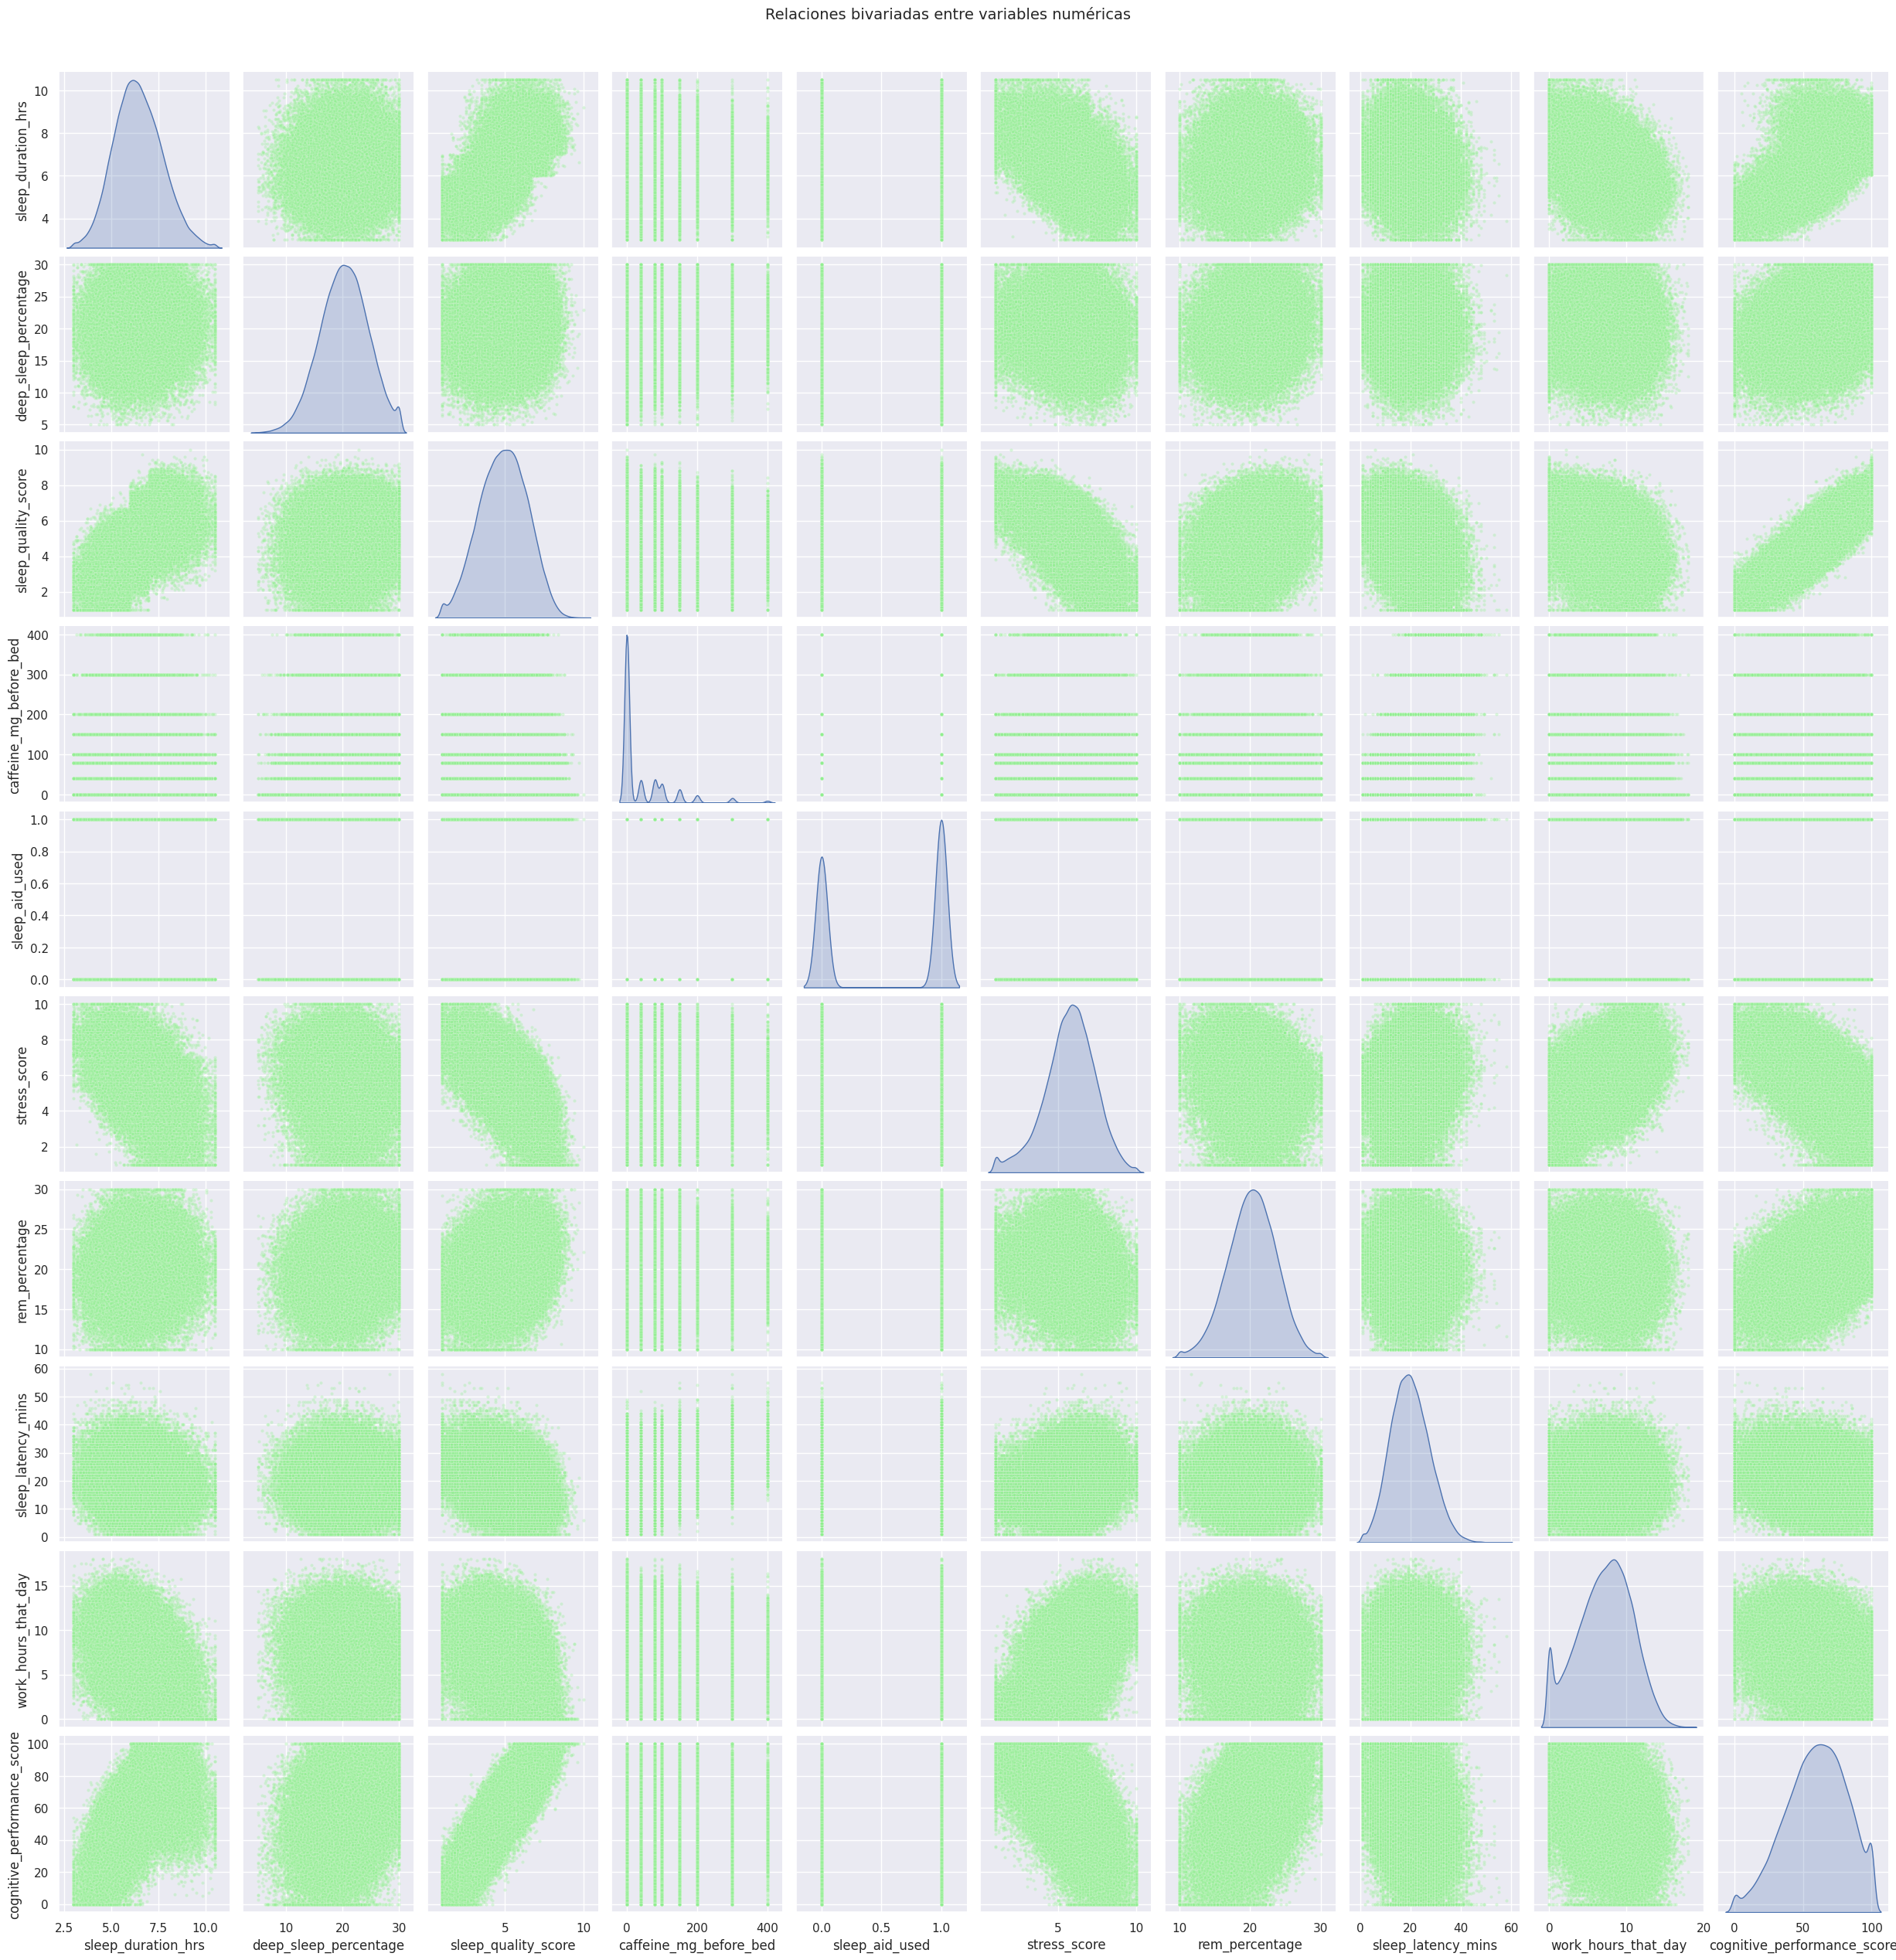

In [ ]:
variables_numericas = df[[
    'sleep_duration_hrs',
    'deep_sleep_percentage',
    'sleep_quality_score',
    'caffeine_mg_before_bed',
    'sleep_aid_used',
    'stress_score',
    'rem_percentage',
    'sleep_latency_mins',
    'work_hours_that_day',
    'cognitive_performance_score'
]]
sns.pairplot(
    variables_numericas,
    diag_kind="kde",
    plot_kws={"alpha":0.3, "s":10, "color": 'lightgreen'}
)
plt.suptitle("Relaciones bivariadas entre variables numéricas", y=1.02, fontsize=14)
plt.show()

▻ **Observaciones:**

En este caso hay algunas relaciones que se ven muy claras.

En la parte de una tendencia ascendente:

* Existe una correlación positiva entre `sleep duration ` y `sleep_quality_score`, ya que se observa y se comprende que a mayor cantidad de horas que una persona duerme, mayor es la puntuación de calidad del sueño.

* También existe una relación muy lineal marcada entre las variables `sleep_quality_score` y `cognitive_performance_score`, entre más aumente la calidad del sueño, más rendimiento cognitivo hay.

En la parte de una tendencia descendiente o negativa:

* Las variables `stress_score` y `sleep_quality_score` se evidencia una correlación negativa, a mayor estrés, menor es la calidad del sueño de la persona.

* Las variables donde más se evidencia una correlación negativa son `stress_score` y `cognitive_performance_score`, se logra evidenciar que a mayor estrés, menor es el rendimiento cognitivo.

* Se observa que a medida que aumentan las `work_hours_that_day`, el `stress_score` tiende a subir, y la `sleep_duration_hrs` tiende a disminuir. Es el clásico ciclo de "mucho trabajo, poco sueño, mucho estrés".

En el caso de las distribuciones:

* Se puede observar que las distribuciones que son de variables categoricas (En este caso 0 y 1), tienen dos picos.

En término general, la variable objetivo `cognitive_performance_score`, muestra que sus relaciones lineales más fuertes y directas se dan con la calidad del sueño (positiva) y el nivel de estrés (negativa). Aunque la duración total del sueño y el porcentaje de sueño profundo también muestran una tendencia ascendente, la dispersión es mayor, lo que sugiere que no basta con dormir mucho.

Por otro lado, variables como la cafeína o las horas de trabajo no presentan una línea recta clara, lo que indica que su impacto en el rendimiento no es constante.


###**Descripción de los Datos Cualitativos**

---

####**Medidas de Asociación entre Variables Categóricas**

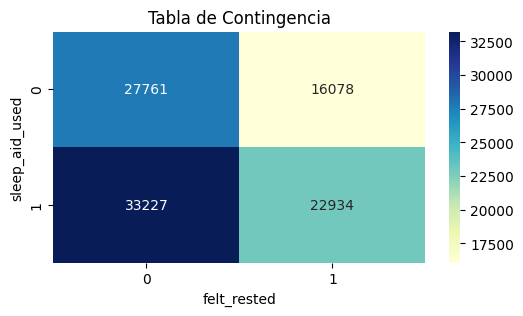

In [ ]:
tabla_contingencia = pd.crosstab(
    df["sleep_aid_used"],
    df["felt_rested"]
)

plt.figure(figsize=(6,3))
sns.heatmap(tabla_contingencia, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Tabla de Contingencia")
plt.show()

▻ **Observación:**

Al observar la tabla de contingencia, se nota que incluso entre quienes usan medicamentos (`sleep_aid_used = 1`), una gran mayoría (33,227 frente a 22,934) sigue reportando no sentirse descansada (`felt_rested = 0`), lo que apoya más la idea de que hay otros factores mucho más influyentes en el descanso.

In [ ]:
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("\nChi²:", chi2)
print("p-valor:", p)
print("Grados de libertad:", dof)

if p < 0.05:
    print("Hay una asociación significativa entre las variables.")
else:
    print("No hay una asociación significativa entre las variables.")

n = tabla_contingencia.sum().sum()
min_dim = min(tabla_contingencia.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print("\nCramér's V:", cramers_v)

if cramers_v < 0.1:
    print("Relación débil.")
elif 0.1 <= cramers_v < 0.3:
    print("Relación baja.")
elif 0.3 <= cramers_v < 0.5:
    print("Relación moderada.")
else:
    print("Relación fuerte.")


Chi²: 178.9933780691386
p-valor: 8.039148608085938e-41
Grados de libertad: 1
Hay una asociación significativa entre las variables.

Cramér's V: 0.04230760901648054
Relación débil.


▻ **Observación:**

Los resultados muestran que, aunque estadísticamente existe una conexión entre `sleep_aid_used` y `felt_rested`, la importancia práctica de esta relación es mínima en este conjunto de datos.

El **p-valor** es extremadamente pequeño y cumple con: $valor\_p \leq 0.05$, lo que confirma que **sí existe una asociación estadísticamente significativa** entre las variables categóricas.

Por otro lado, el valor de **Cramér's V** (0.042) al estar tan cerca de cero, indica que la fuerza de esa relación es **muy débil**. Esto sugiere que el uso de una ayuda para dormir no es un predictor determinante para saber si alguien se sentirá descansado.





####**Evaluación de Ajuste a Distribución Normal**

Se evaluó la normalidad de la variable objetivo `cognitive_performance_score` mediante gráficos como el QQ-Plot, histograma y boxplot.

Esto permite identificar desviaciones de la distribución normal, presencia de asimetrías y valores atípicos.



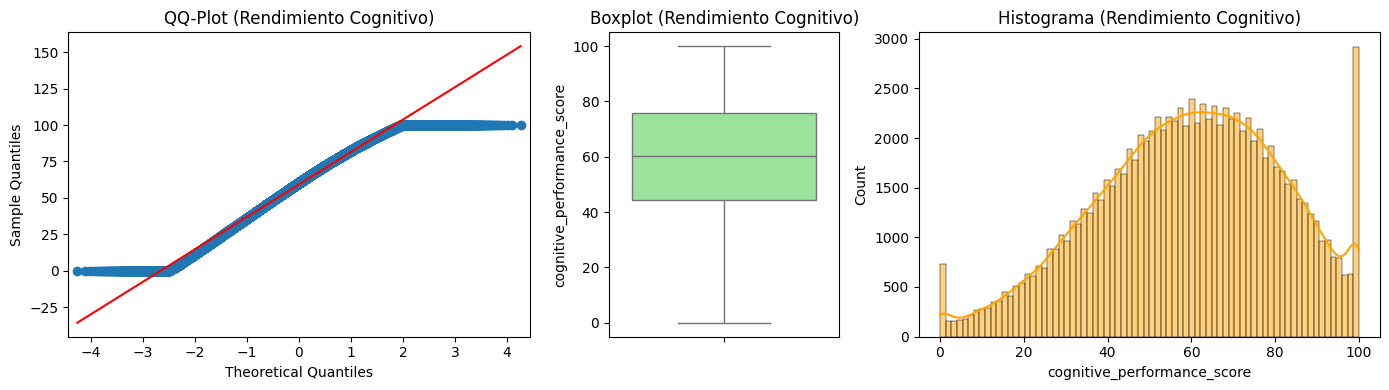

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14,4), width_ratios=[2, 1, 2])

sm.qqplot(df['cognitive_performance_score'], line='s', ax=axes[0])
axes[0].set_title("QQ-Plot (Rendimiento Cognitivo)")

sns.boxplot(y=df['cognitive_performance_score'], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot (Rendimiento Cognitivo)")

sns.histplot(df['cognitive_performance_score'], kde=True, ax=axes[2], color='orange')
axes[2].set_title("Histograma (Rendimiento Cognitivo)")

plt.tight_layout()
plt.show()

▻ **Observaciones:**

* **QQ-Plot:** Se ajusta entre los valores -2 y 2, pero hay falta de ajuste en los extremos, lo que confirma que la variable tiene limites. Por lo tanto la distribucion no es una normal perfecta.

* **Boxplot (Simetría y Outliers):** El gráfico no muestra outliers. La caja es bastante simétrica con una mediana cercana a 60, lo que indica que el grueso de los datos está bien distribuido en el centro, aunque los bigotes son largos sobre todo el que llega al extremo donde está el 0 y puede explicar del porque el histograma se ve un poco estirado a la izquierda.

* **Histograma:** Hay una acumulación de registros que alcanzaron el puntaje máximo, lo que rompe la forma de campana suave y crea esos picos aislados en los bordes, también hay un pico en el minimo, todos estos picos indican poca variabilidad.


In [ ]:
# Prueba de normalidad
stat, p = kstest(df['cognitive_performance_score'], cdf='norm')
print("Kolmogorov-Smirnov:")
print(f"  Estadístico={stat:.4f}, p-valor={p:.4f}")
if p > 0.05:
    print("  No se rechaza la normalidad (distribución compatible con normal)\n")
else:
    print("  Se rechaza la normalidad\n")

Kolmogorov-Smirnov:
  Estadístico=0.9901, p-valor=0.0000
  Se rechaza la normalidad



▻ **Observación:**

Para saber si realmente la variable sigue una distribución normal, usamos la prueba de normalidad.

El test de Kolmogorov-Smirnov dió como resultado un estadístico de 0.9901 y un p-valor de 0.0000. Dado que el p-valor es menor a 0.05, se rechaza la hipótesis nula de normalidad.

**Por lo tanto, se concluye que la variable no sigue una distribución normal.**

###**Descripción de los Datos Cuantitativos + binarios**

---

In [ ]:
variables_numericas = df[[
    'sleep_duration_hrs',
    'deep_sleep_percentage',
    'sleep_quality_score',
    'caffeine_mg_before_bed',
    'sleep_aid_used',
    'stress_score',
    'rem_percentage',
    'sleep_latency_mins',
    'work_hours_that_day',
    'cognitive_performance_score',
    'felt_rested'

]]

In [ ]:
variables_numericas.describe()

,sleep_duration_hrs,deep_sleep_percentage,sleep_quality_score,caffeine_mg_before_bed,sleep_aid_used,stress_score,rem_percentage,sleep_latency_mins,work_hours_that_day,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,6.423986,20.253375,4.871144,38.849500,0.561610,5.733285,20.243968,19.836810,7.134059,59.227295,0.390120
std,1.274627,4.251096,1.506517,69.395818,0.496192,1.619194,3.411354,7.584343,3.482878,22.249665,0.487779
min,3.000000,5.000000,1.000000,0.000000,0.000000,1.000000,10.000000,1.000000,0.000000,0.000000,0.000000
25%,5.530000,17.400000,3.800000,0.000000,0.000000,4.800000,18.000000,14.000000,4.700000,44.200000,0.000000
50%,6.360000,20.300000,4.900000,0.000000,1.000000,5.800000,20.300000,19.000000,7.400000,60.400000,0.000000
75%,7.270000,23.200000,6.000000,80.000000,1.000000,6.800000,22.600000,25.000000,9.700000,75.800000,1.000000
max,10.500000,30.000000,10.000000,400.000000,1.000000,10.000000,30.000000,58.000000,18.000000,100.000000,1.000000


A partir de los estadísticos descriptivos de las variables cuantitativas, se observa que estas presentan diferencias significativas en sus escalas y rangos de variación. Por ejemplo, la variable caffeine_mg_before_bed toma valores entre 0 y 400, mientras que variables como stress_score se encuentran en un rango de 1 a 10.

De igual forma, variables como cognitive_performance_score presentan un rango de 0 a 100, mientras que otras como sleep_duration_hrs oscilan aproximadamente entre 3 y 10.5 horas. Estas diferencias evidencian una clara heterogeneidad en las unidades de medida y magnitudes de las variables.

Cabe resaltar que la variable sleep_aid_used es de naturaleza binaria (0–1), por lo cual no se incluye dentro del análisis de escalas de variables continuas, dado que su interpretación no depende de magnitudes comparables.

La disparidad en las escalas de las variables continuas puede afectar la interpretación de los coeficientes en el modelo de regresión lineal múltiple, dado que variables con mayor rango pueden dominar el ajuste del modelo sin necesariamente reflejar una mayor influencia real sobre la variable objetivo.

En consecuencia, se considera pertinente aplicar un proceso de estandarización mediante transformación Z-score a las variables independientes continuas, con el fin de homogenizar sus escalas, facilitar la comparación entre coeficientes y mejorar la estabilidad numérica del modelo.

In [ ]:
# Dividir el conjunto para entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(variables_numericas, variables_numericas['cognitive_performance_score'], test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80000, 11), (20000, 11), (80000,), (20000,))

In [ ]:
X_train.corr()

,sleep_duration_hrs,deep_sleep_percentage,sleep_quality_score,caffeine_mg_before_bed,sleep_aid_used,stress_score,rem_percentage,sleep_latency_mins,work_hours_that_day,cognitive_performance_score,felt_rested
sleep_duration_hrs,1.000000,0.048263,0.646306,-0.020228,0.113768,-0.498274,0.062491,-0.126895,-0.440249,0.618411,0.441533
deep_sleep_percentage,0.048263,1.000000,0.093855,-0.005374,-0.008834,-0.094241,0.120795,-0.022642,-0.038425,0.283366,0.052111
sleep_quality_score,0.646306,0.093855,1.000000,-0.050719,0.048131,-0.638109,0.255544,-0.290722,-0.365572,0.860198,0.477365
caffeine_mg_before_bed,-0.020228,-0.005374,-0.050719,1.000000,-0.001139,0.000065,0.000625,0.322291,0.001912,-0.065248,-0.024341
sleep_aid_used,0.113768,-0.008834,0.048131,-0.001139,1.000000,0.005292,-0.007062,-0.000866,0.004454,0.045547,0.041120
stress_score,-0.498274,-0.094241,-0.638109,0.000065,0.005292,1.000000,-0.158946,0.166618,0.490414,-0.592482,-0.364587
rem_percentage,0.062491,0.120795,0.255544,0.000625,-0.007062,-0.158946,1.000000,-0.027195,-0.063840,0.446981,0.122402
sleep_latency_mins,-0.126895,-0.022642,-0.290722,0.322291,-0.000866,0.166618,-0.027195,1.000000,0.049141,-0.223611,-0.123555
work_hours_that_day,-0.440249,-0.038425,-0.365572,0.001912,0.004454,0.490414,-0.063840,0.049141,1.000000,-0.343490,-0.247811
cognitive_performance_score,0.618411,0.283366,0.860198,-0.065248,0.045547,-0.592482,0.446981,-0.223611,-0.343490,1.000000,0.450830


####**Matriz de Correlación de las Variables Númericas**

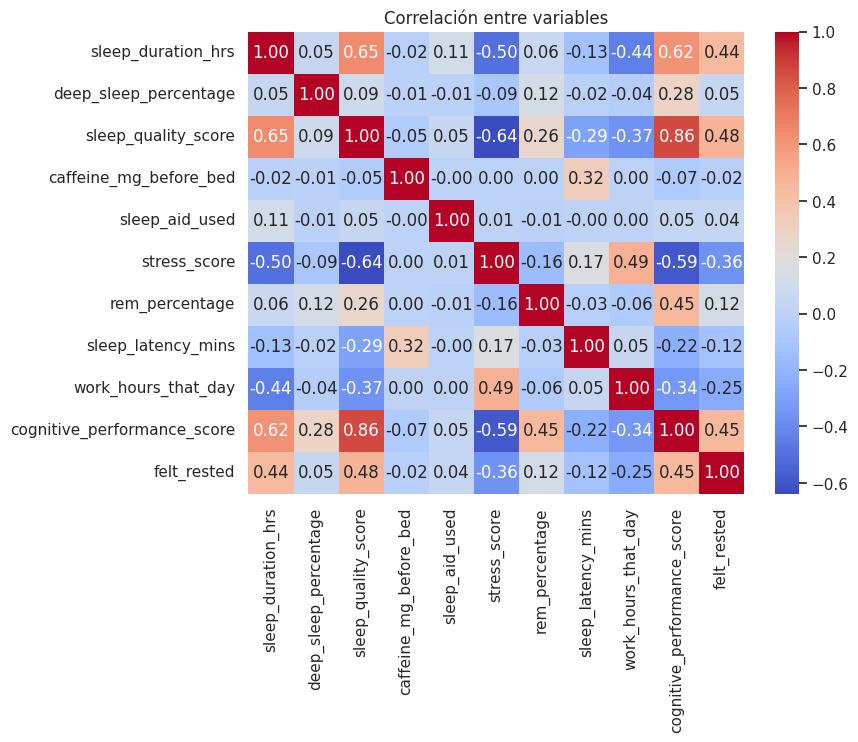

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre variables')
plt.show()

A partir de la matriz de correlación, se identifican varias relaciones relevantes entre las variables independientes y la variable objetivo (cognitive_performance_score).

En primer lugar, destaca la variable sleep_quality_score, la cual presenta una correlación alta de 0.86 con la variable objetivo, lo que sugiere una fuerte relación lineal positiva y la posiciona como uno de los principales predictores del modelo. De igual forma, variables como sleep_duration_hrs (0.62) y stress_score (-0.59) evidencian asociaciones moderadas a fuertes, indicando que una mayor duración del sueño se relaciona con un mejor desempeño cognitivo, mientras que niveles más altos de estrés se asocian negativamente con este.

Otras variables como rem_percentage (0.45) y felt_rested (0.45) también presentan correlaciones moderadas, lo que sugiere que podrían aportar información relevante al modelo.

En cuanto a las relaciones entre variables independientes, se observan algunas correlaciones moderadas, como la existente entre sleep_duration_hrs y sleep_quality_score (0.65), así como entre sleep_quality_score y stress_score (-0.64). No obstante, estos valores no son lo suficientemente altos como para concluir la presencia de multicolinealidad severa, aunque sí sugieren la posibilidad de relaciones lineales que deberán ser evaluadas con mayor precisión.

Estos hallazgos son consistentes con el análisis exploratorio previo basado en gráficos de dispersión, donde se evidenciaron tendencias lineales claras, como la relación positiva entre sleep_quality_score y el rendimiento cognitivo, así como relaciones negativas con variables como stress_score. Asimismo, se observó que variables como sleep_duration_hrs y rem_percentage presentan tendencias ascendentes con mayor dispersión, mientras que otras como el consumo de cafeína o las horas de trabajo no muestran relaciones lineales tan definidas.

En conjunto, la presencia de estas relaciones aproximadamente lineales entre múltiples variables explicativas y la variable objetivo sugiere que un modelo de regresión lineal múltiple puede ser una opción viable para capturar y cuantificar estos efectos de manera simultánea.

En este sentido, si bien existe evidencia de asociaciones lineales relevantes entre las variables regresoras y la variable objetivo, también se reconoce la necesidad de evaluar formalmente la multicolinealidad mediante el cálculo del Factor de Inflación de la Varianza (VIF).

A partir de este análisis, se procederá a la construcción del modelo, considerando como criterios de selección la significancia estadística de los coeficientes (valores p) y los niveles de multicolinealidad (VIF), eliminando progresivamente aquellas variables que no aporten al modelo o que generen redundancia en la información.

Para la depuración del modelo, se considerarán los siguientes criterios:

* Variables con valor p alto y VIF alto serán candidatas a eliminación inmediata.
* Variables con valor p alto y VIF bajo serán evaluadas por su baja contribución al modelo.
* Variables con valor p bajo y VIF alto serán revisadas cuidadosamente, dado que pueden aportar información relevante pero estar afectadas por multicolinealidad.
* Variables con valor p bajo y VIF bajo serán retenidas en el modelo.

# **CONSTRUCCIÓN Y VALIDACIÓN DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE:**




In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Definir columnas
columnas_a_estandarizar = [
    'sleep_duration_hrs',
    'deep_sleep_percentage',
    'sleep_quality_score',
    'caffeine_mg_before_bed',
    'stress_score',
    'rem_percentage',
    'sleep_latency_mins',
    'work_hours_that_day',
    'cognitive_performance_score'
]

columnas_binarias = ['sleep_aid_used', 'felt_rested']  # Se pasan tal cual

# Crear el ColumnTransformer
preprocesador = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), columnas_a_estandarizar),
    ('passthrough', 'passthrough', columnas_binarias)
])

# Ajustar y transformar
estandarizados = preprocesador.fit_transform(X_train)

# Reconstruir el DataFrame (el orden sigue el de los transformers)
X_train = pd.DataFrame(estandarizados, columns=columnas_a_estandarizar + columnas_binarias)

X_train.describe().round(3)

,sleep_duration_hrs,deep_sleep_percentage,sleep_quality_score,caffeine_mg_before_bed,stress_score,rem_percentage,sleep_latency_mins,work_hours_that_day,cognitive_performance_score,sleep_aid_used,felt_rested
count,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000
mean,-0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000,0.560,0.389
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.496,0.488
min,-2.688,-3.583,-2.571,-0.559,-2.926,-3.005,-2.482,-2.055,-2.659,0.000,0.000
25%,-0.701,-0.671,-0.710,-0.559,-0.577,-0.659,-0.769,-0.674,-0.679,0.000,0.000
50%,-0.049,0.010,0.021,-0.559,0.041,0.016,-0.110,0.074,0.058,1.000,0.000
75%,0.665,0.690,0.752,0.592,0.659,0.690,0.681,0.735,0.745,1.000,1.000
max,3.202,2.287,3.411,5.194,2.637,2.860,5.030,3.123,1.831,1.000,1.000


In [ ]:
# Para X_test — solo transform, nunca fit_transform
estandarizados_test = preprocesador.transform(X_test)
X_test = pd.DataFrame(estandarizados_test, columns=columnas_a_estandarizar + columnas_binarias)

fin de estandarización

In [ ]:
# Dividir dependiente e independientes
X_train = X_train.drop('cognitive_performance_score', axis=1)
X_test = X_test.drop('cognitive_performance_score', axis=1)
X_train.shape, X_test.shape

((80000, 10), (20000, 10))

In [ ]:
# Se ajustan los índices de los conjuntos de datos
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
# Agregar constante para el intercepto (β0)
X_train = sm.add_constant(X_train)

A continuación, se diseña el modelo OLS, se ajusta con el método `.fit()` y se presenta un resumen de su resultado. Así mismo, se calculan los VIF's y se presenta una tabla con estos valores para cada variable incluida en el modelo. Esto nos ayuda a identificar si una variable no resulta significativa para el modelo o genera alta multicolinealidad en el conjunto de independientes.

In [ ]:
# Ajustar modelo de regresión
modelo1 = sm.OLS(y_train, X_train).fit()
resumen = modelo1.summary2().tables[1].round(3) # summary2 sirve para extraer tablas
#print(resumen)
print(modelo1.summary(),'\n')

valores_p = modelo1.pvalues.drop('const')
print(f'Variable con mayor valor_p: {valores_p.idxmax()} ({valores_p.max():.4f})', '\n') # Devuelve etiqueta (índice) del valor máximo

# Crear tabla con VIFs
vif = pd.DataFrame()
vif['Variable'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i)
                   for i in range(X_train.shape[1])]

print(vif.round(2))

                                 OLS Regression Results                                
Dep. Variable:     cognitive_performance_score   R-squared:                       0.844
Model:                                     OLS   Adj. R-squared:                  0.844
Method:                          Least Squares   F-statistic:                 4.322e+04
Date:                         Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                                 14:20:02   Log-Likelihood:            -2.8750e+05
No. Observations:                        80000   AIC:                         5.750e+05
Df Residuals:                            79989   BIC:                         5.751e+05
Df Model:                                   10                                         
Covariance Type:                     nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

En el modelo de regresión lineal múltiple construido, se observa una capacidad explicativa alta, con un coeficiente de determinación de R² = 0.844 y un R² ajustado igualmente de 0.844, lo que indica que el modelo logra explicar el 84.4% de la variabilidad de la variable objetivo (cognitive_performance_score). La cercanía entre ambos valores sugiere además la ausencia de sobreajuste significativo.

En cuanto a la significancia global del modelo, el estadístico F presenta un valor elevado (4.32e+04) con un p-valor asociado de 0.00, lo que permite rechazar la hipótesis nula de que todos los coeficientes son iguales a cero. En consecuencia, se concluye que el modelo es globalmente significativo.

A nivel individual, la mayoría de las variables independientes presentan valores p inferiores a 0.05, lo que indica que son estadísticamente significativas para explicar el comportamiento de la variable objetivo. Entre ellas, destacan variables como sleep_quality_score, sleep_duration_hrs y stress_score, las cuales ya habían mostrado relaciones relevantes en el análisis exploratorio previo.

No obstante, la variable sleep_aid_used presenta un valor p de 0.862, lo que indica que no es significativa dentro del modelo. Dado que además no presenta problemas de multicolinealidad (VIF cercano a 1), se concluye que su aporte explicativo es mínimo, por lo que será eliminada en el siguiente ciclo de modelado.

En relación con la multicolinealidad, los valores del Factor de Inflación de la Varianza (VIF) para todas las variables se encuentran por debajo de 3, lo que indica que no existen problemas severos de colinealidad entre las variables independientes.

Finalmente, las pruebas de normalidad de los residuos (Omnibus y Jarque-Bera) indican desviaciones respecto a la normalidad. Sin embargo, dado el gran tamaño de la muestra (80,000 observaciones), este resultado no se considera crítico para la validez del modelo, apoyándose en el teorema del límite central.

Con base en estos resultados, se procederá a realizar un nuevo ciclo de modelado, eliminando la variable sleep_aid_used y evaluando nuevamente el desempeño del modelo, buscando mantener su capacidad explicativa sin incorporar variables irrelevantes.

In [ ]:
# Actualizando el conjunto de independientes de prueba sin la variable a remover
X_train2 = X_train.drop(columns=['sleep_aid_used'])
X_train2

# Recalculando el modelo sin esa variable
modelo2 = sm.OLS(y_train, X_train2).fit()
print(modelo2.summary(),'\n')

# Obteniendo valores p
valores_p2 = modelo2.pvalues.drop('const')
print(f'Variable con mayor valor_p: {valores_p2.idxmax()} ({valores_p2.max():.4f})', '\n')

# Crear tabla con VIFs
vif2 = pd.DataFrame()
vif2['Variable'] = X_train2.columns
vif2['VIF'] = [variance_inflation_factor(X_train2.values, i)
                   for i in range(X_train2.shape[1])]

print(vif2.round(2))

                                 OLS Regression Results                                
Dep. Variable:     cognitive_performance_score   R-squared:                       0.844
Model:                                     OLS   Adj. R-squared:                  0.844
Method:                          Least Squares   F-statistic:                 4.803e+04
Date:                         Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                                 14:20:07   Log-Likelihood:            -2.8750e+05
No. Observations:                        80000   AIC:                         5.750e+05
Df Residuals:                            79990   BIC:                         5.751e+05
Df Model:                                    9                                         
Covariance Type:                     nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

En esta última iteración, se obtuvo un modelo de regresión lineal múltiple en el cual todas las variables incluidas resultan estadísticamente significativas, con valores p inferiores a 0.05. Asimismo, los valores del Factor de Inflación de la Varianza (VIF) se mantienen por debajo de 3 para todas las variables, lo que indica la ausencia de problemas relevantes de multicolinealidad.

El modelo presenta un coeficiente de determinación de R² = 0.844 y un R² ajustado de 0.844, lo que implica que logra explicar el 84.4% de la variabilidad observada en la variable objetivo (cognitive_performance_score). En comparación con la iteración anterior, el modelo mantiene su capacidad explicativa sin necesidad de incluir variables no significativas, lo que refleja una mejora en términos de parsimonia.

Dado que todas las variables actuales aportan de manera significativa al modelo y no se evidencian problemas de colinealidad, no se considera necesario continuar con la eliminación de variables, ya que esto podría reducir la capacidad explicativa del modelo sin aportar mejoras sustanciales.

El modelo resultante se expresa de la siguiente forma:

$$
cognitive\_performance\_score = 58.8190
+ 3.1971 \cdot sleep\_duration\_hrs
+ 4.0303 \cdot deep\_sleep\_percentage
+ 14.5878 \cdot sleep\_quality\_score
- 0.7364 \cdot caffeine\_mg\_before\_bed
- 1.0450 \cdot stress\_score
+ 5.3362 \cdot rem\_percentage
+ 0.3662 \cdot sleep\_latency\_mins
+ 0.2060 \cdot work\_hours\_that\_day
+ 1.0230 \cdot felt\_rested
$$

Por otro lado, se analiza la significancia global del modelo mediante el estadístico F. En este caso, se obtiene un valor de Prob (F-statistic) = 0.00, el cual es menor a 0.05, lo que permite rechazar la hipótesis nula de que todos los coeficientes son iguales a cero. En consecuencia, se concluye que el modelo en su conjunto es estadísticamente significativo y que al menos una de las variables independientes contribuye de manera relevante a la explicación de la variable dependiente.

###**Medidas de Calidad de Ajuste y Graficas**

In [ ]:
# Ajustar el conjunto de prueba a la reducción de variables que se hizo
X_test = X_test.drop(columns=['sleep_aid_used'])
X_test.shape

(20000, 9)

In [ ]:
# Estandarizamos las variables
escalador = StandardScaler()

# Ajustar el escalador a los datos
estandarizados = escalador.fit_transform(X_test)

# Convertir el resultado a DataFrame
X_test = pd.DataFrame(estandarizados, columns=X_test.columns)
X_test.describe().round(3)

,sleep_duration_hrs,deep_sleep_percentage,sleep_quality_score,caffeine_mg_before_bed,stress_score,rem_percentage,sleep_latency_mins,work_hours_that_day,felt_rested
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.681,-3.609,-2.563,-0.565,-2.913,-2.996,-2.489,-2.021,-0.805
25%,-0.695,-0.694,-0.715,-0.565,-0.574,-0.653,-0.772,-0.711,-0.805
50%,-0.046,0.017,0.011,-0.565,0.042,0.020,0.020,0.058,-0.805
75%,0.666,0.680,0.737,0.598,0.657,0.694,0.680,0.742,1.242
max,3.183,2.316,2.981,5.248,2.627,2.860,4.379,3.049,1.242


In [ ]:
# Agregamos vector de constantes
X_test = sm.add_constant(X_test)

In [ ]:
# Predecimos sobre el conjunto de prueba
y_pred = modelo2.predict(X_test)

# Métricas de error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² (test): {r2:.4f}")

MAE: 7.03
MSE: 78.72
RMSE: 8.87
R² (test): 0.8398


Las métricas obtenidas permiten evaluar el desempeño del modelo en el conjunto de prueba, es decir, su capacidad de generalización a datos no vistos.

El MAE (Mean Absolute Error) = 7.03 indica que, en promedio, las predicciones del modelo se desvían aproximadamente 7 unidades del valor real del cognitive_performance_score. Esto da una medida directa y fácil de interpretar del error típico del modelo.

El MSE = 78.72 y el RMSE = 8.87 penalizan más fuertemente los errores grandes. En particular, el RMSE sugiere que los errores más significativos tienen un impacto relevante en el modelo, siendo ligeramente mayor que el MAE. Esto puede indicar la presencia de algunas predicciones con errores relativamente altos.

Por otro lado, el R² (test) = 0.8398 indica que el modelo es capaz de explicar aproximadamente el 84% de la variabilidad del rendimiento cognitivo en el conjunto de prueba. Este es un resultado bastante sólido, lo que sugiere que el modelo tiene una buena capacidad predictiva y logra capturar la mayoría de las relaciones relevantes entre las variables.

En conjunto, las métricas muestran que el modelo tiene un buen desempeño general, con errores moderados y una alta proporción de varianza explicada. Sin embargo, la diferencia entre MAE y RMSE sugiere que podría haber algunos casos donde el modelo no predice tan bien, lo cual sería consistente con observaciones previas como la ligera subestimación en valores altos. Esto indica que, aunque el modelo es adecuado, aún hay margen de mejora, especialmente en la predicción de valores extremos.

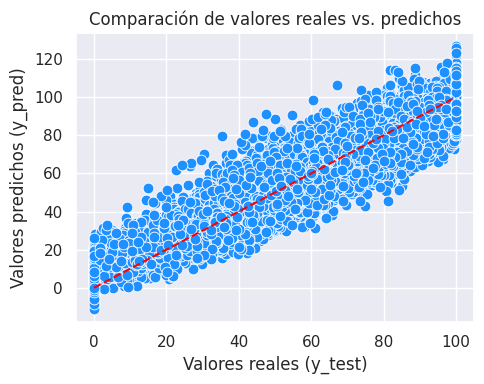

In [ ]:
# 3. Gráfico de valores reales vs. predichos
plt.figure(figsize=(5,4))
sns.scatterplot(x=y_test, y=y_pred, color='dodgerblue', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Valores reales (y_test)')
plt.ylabel('Valores predichos (y_pred)')
plt.title('Comparación de valores reales vs. predichos')
plt.grid(True)
plt.tight_layout() # para ajustar automáticamente espacios entre subplots y bordes de la figura evitando que se solapen etiquetas, títulos o ejes.
plt.show()

In [ ]:
y_test.max()

100.0

En esta gráfica, el eje X representa los valores reales de la variable objetivo (cognitive_performance_score), mientras que el eje Y muestra los valores predichos por el modelo. La línea roja punteada corresponde a la línea ideal de predicción perfecta (y = ŷ), donde los valores predichos coinciden exactamente con los reales.

Se observa que la nube de puntos sigue una tendencia lineal positiva clara y bastante cercana a la línea ideal, lo que indica que el modelo logra capturar adecuadamente la relación entre las variables explicativas y el rendimiento cognitivo. Esta alineación refuerza el buen desempeño previamente evidenciado en el coeficiente de determinación (R²).

No obstante, también se aprecia cierta dispersión alrededor de la línea, especialmente en valores más altos de la variable objetivo (por encima de 80–100), donde el modelo tiende a subestimar ligeramente algunos valores reales. Este comportamiento sugiere que, aunque el modelo es consistente en términos generales, su precisión disminuye en los extremos superiores.

A esto se suma un hallazgo adicional: el modelo genera predicciones fuera del rango válido de la variable objetivo (0–100), produciendo valores negativos y superiores a 100. Este comportamiento es inherente a la regresión lineal ordinaria (OLS), que no impone restricciones sobre el rango de salida y simplemente extiende la línea de ajuste más allá de los límites reales de la variable. Esto no invalida el modelo, pero sí representa una limitación práctica que debe tenerse en cuenta al momento de interpretar o utilizar las predicciones.

Adicionalmente, no se observan patrones curvos o estructuras sistemáticas en la distribución de los puntos, lo cual respalda el supuesto de linealidad del modelo. Tampoco se evidencia una presencia significativa de valores atípicos que comprometan el ajuste general.
En conjunto, el modelo muestra un desempeño sólido, logrando aproximar razonablemente bien los valores reales, aunque podría beneficiarse de ajustes adicionales si se desea mejorar la precisión en valores extremos.

**Comprobación de supuestos del modelo**

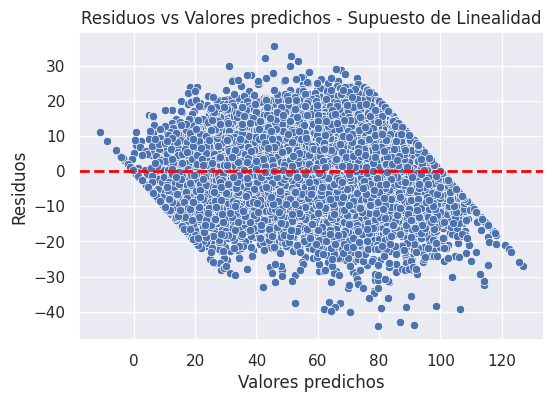

PRUEBA DE ESPECIFICIDAD DEL MODELO - Lineal (Ramsey RESET)
Estadístico F: 2231.401099463601
p-valor: 0.0


In [ ]:
# LINEALIDAD

# Guardamos los residuos
residuos = y_test - y_pred

# Crear la gráfica de residuos vs valores predichos
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(0, color='red', linestyle='--', lw=2)  # Línea horizontal en cero
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores predichos - Supuesto de Linealidad')
plt.show()

# Aplicar la prueba RESET
reset_test = linear_reset(modelo2, power=2, use_f=True)

# Mostrar resultados
print('PRUEBA DE ESPECIFICIDAD DEL MODELO - Lineal (Ramsey RESET)')
print('Estadístico F:', reset_test.fvalue)
print('p-valor:', reset_test.pvalue)

En la gráfica de residuos vs valores predichos, los puntos presentan una dispersión que, a primera vista, parece distribuirse alrededor de la línea roja (cero). Sin embargo, se observa un patrón estructurado en forma de rombo o elipse, donde la dispersión de los residuos es notablemente mayor en los valores predichos intermedios (aproximadamente entre 20 y 80) y se reduce hacia los extremos. Este comportamiento no es aleatorio y sugiere que el modelo no captura completamente la relación entre las variables, lo cual es una señal de una posible violación del supuesto de linealidad.
Ahora bien, la prueba de Ramsey RESET sobre especificidad del modelo puede interpretarse de la siguiente forma:

Si p-valor < 0.05 se rechaza la hipótesis nula H₀ sobre la linealidad del modelo. Esto quiere decir que el modelo está mal especificado: podría faltar una relación no lineal.
Si p-valor > 0.05 no se rechaza H₀, lo que quiere decir que el modelo está bien especificado, lo cual respalda el cumplimiento del supuesto de linealidad.

Dado que el estadístico F = 2231.40 y el p-valor = 0.0, que es menor que 0.05, se rechaza contundentemente la hipótesis nula H₀ sobre la linealidad del modelo. Esto indica que el modelo está mal especificado y que probablemente existen relaciones no lineales entre las variables predictoras y la variable dependiente que el modelo actual no está capturando.
Por lo anterior, el supuesto de linealidad no se cumple, lo cual es consistente con el patrón estructurado observado en la gráfica y sugiere la necesidad de explorar transformaciones de variables o la inclusión de términos no lineales para mejorar la especificación del modelo.

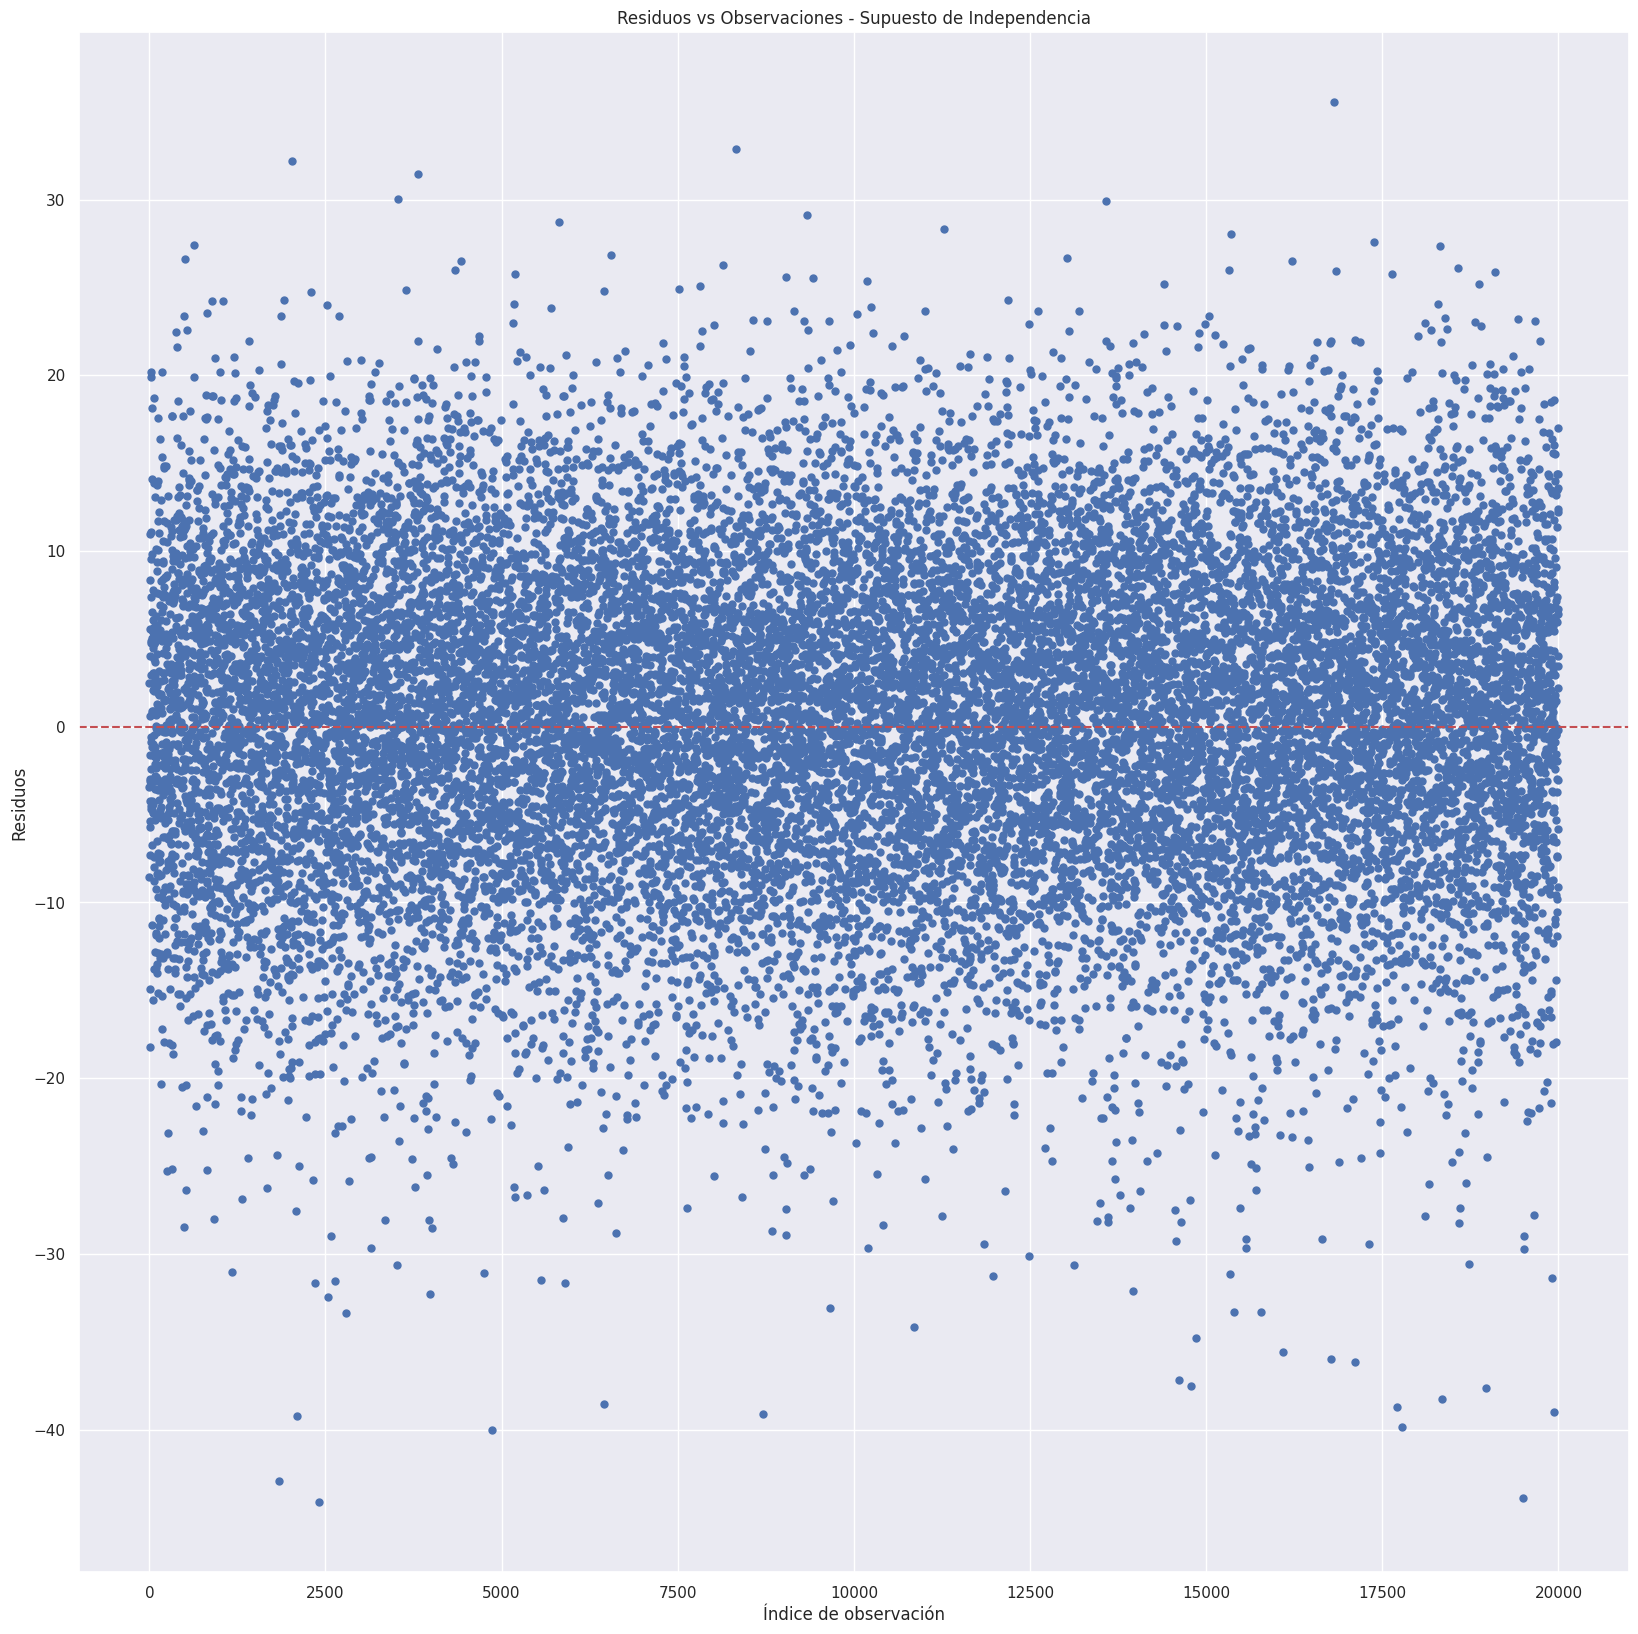

Estadístico Durbin-Watson: 1.9680


In [ ]:
# INDEPENDENCIA

plt.figure(figsize=(20,20))
plt.plot(residuos, marker='o', linestyle='', ms=5) # ms (marker size)
plt.axhline(y=0, color='r', linestyle='--')

plt.scatter(range(len(residuos)), residuos, alpha=0.3, s=5)
plt.title('Residuos vs Observaciones - Supuesto de Independencia')
plt.xlabel('Índice de observación')
plt.ylabel('Residuos')
plt.show()

# --- Test de Durbin-Watson ---
dw = durbin_watson(residuos)
print(f'Estadístico Durbin-Watson: {dw:.4f}')

En la gráfica de residuos frente al índice de observación, se espera que los puntos estén distribuidos de forma aleatoria alrededor de la línea horizontal en cero, sin seguir ningún patrón específico.

En este caso, los residuos se ven bastante dispersos y no presentan tendencias claras ni comportamientos cíclicos a lo largo de las observaciones, lo que sugiere que no hay una relación entre los errores consecutivos. Es decir, visualmente se cumple el supuesto de independencia.

Por otro lado, el estadístico de Durbin-Watson obtenido es de aproximadamente 1.968, un valor muy cercano a 2. Esto indica que no hay evidencia de autocorrelación en los residuos, ya que valores cercanos a 2 sugieren independencia, mientras que valores cercanos a 0 o 4 indicarían autocorrelación positiva o negativa, respectivamente.

En conjunto, tanto la gráfica como el resultado del test permiten concluir que el supuesto de independencia de los residuos se cumple de manera adecuada en el modelo.

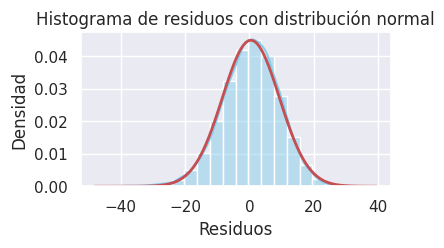

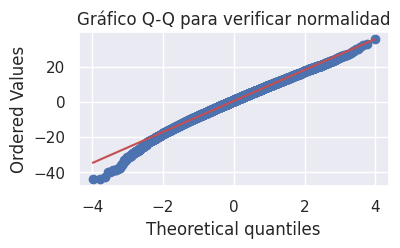

Shapiro-Wilk Test:
Estadístico: 0.9958316208565217
p-valor: 3.283320405159144e-23


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20000.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# NORMALIDAD

# Histograma con curva normal
plt.figure(figsize=(4,2))
sns.histplot(residuos, kde=True, stat="density", bins=20, color='skyblue')
xmin, xmax = plt.xlim() # Para extraer los límines actuales que serán usados en el eje X del gráfico de la distribución normal
x = np.linspace(xmin, xmax, 100) # Se generan puntos para usarlos en el eje X del gráfico de la distribución normal
p = st.norm.pdf(x, residuos.mean(), residuos.std()) # Se genera el gráfico de la distribución normal con los valores del eje X y los residuos
plt.plot(x, p, 'r', linewidth=2) #  Se grafica la curva de la distribución normal dentro del mismo rango del histograma.
plt.title('Histograma de residuos con distribución normal')
plt.xlabel('Residuos')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

# Gráfico Q-Q
plt.figure(figsize=(4,2))
st.probplot(residuos, dist="norm", plot=plt)
plt.title("Gráfico Q-Q para verificar normalidad")
plt.grid(True)
plt.show()

# Prueba de Shapiro-Wilk
shapiro_test = st.shapiro(residuos)
print("Shapiro-Wilk Test:")
print("Estadístico:", shapiro_test.statistic)
print("p-valor:", shapiro_test.pvalue)

El histograma de los residuos muestra una distribución aproximadamente simétrica y centrada en cero, lo cual es consistente con el comportamiento esperado bajo el supuesto de normalidad. Sin embargo, al compararlo con la curva normal teórica, se observan ligeras desviaciones, especialmente en las colas, lo que indica que la distribución no es perfectamente normal.

Este comportamiento se confirma en el gráfico Q-Q, donde la mayoría de los puntos siguen la línea diagonal, particularmente en la zona central, lo que sugiere un buen ajuste a la normalidad en ese rango. No obstante, en los extremos se evidencian desviaciones más marcadas, con puntos que se alejan de la línea, lo que podría indicar la presencia de colas más pesadas o ciertos valores atípicos.

En cuanto a la prueba de Shapiro-Wilk, el p-valor obtenido es extremadamente bajo (≈ 0), lo que lleva a rechazar la hipótesis nula de normalidad. Sin embargo, es importante tener en cuenta que el tamaño de la muestra es considerablemente grande (N ≈ 20000), lo que hace que esta prueba sea muy sensible a pequeñas desviaciones. De hecho, incluso diferencias leves respecto a la normalidad pueden resultar estadísticamente significativas en este contexto.

Adicionalmente, este resultado es coherente con el análisis exploratorio previo de la variable objetivo (cognitive_performance_score), donde se evidenció que no seguía una distribución normal, presentando acumulaciones en los valores extremos (especialmente en el máximo) y cierta limitación en su rango. Este tipo de comportamiento puede generar, de forma natural, desviaciones en la distribución de los residuos, particularmente en las colas.

Por lo tanto, aunque desde un punto de vista estrictamente estadístico se rechaza la normalidad, visual y prácticamente los residuos no presentan desviaciones severas, y el supuesto puede considerarse razonablemente cumplido para fines predictivos. No obstante, estas desviaciones deben tenerse en cuenta en caso de realizar inferencias más rigurosas basadas en la normalidad de los errores.

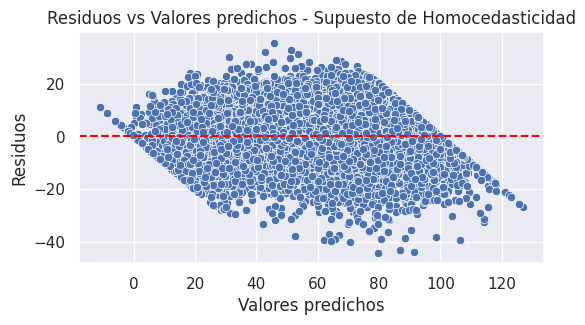

Estadístico LM: 838.8947847108752
p-valor LM: 8.988131006603195e-175
Estadístico F: 97.24274807946523
p-valor F: 1.3044727678629216e-178


In [ ]:
# HOMOSCEDASTICIDAD

# Gráfico de residuos vs valores predichos
plt.figure(figsize=(6,3))
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores predichos - Supuesto de Homocedasticidad")
plt.show()

# Prueba de Breusch-Pagan
#X_const = sm.add_constant(X_train)
bp_test = het_breuschpagan(residuos, X_test)

labels = ['Estadístico LM', 'p-valor LM', 'Estadístico F', 'p-valor F']
for name, value in zip(labels, bp_test):
    print(f"{name}: {value}")

La prueba de Breusch-Pagan se utiliza para detectar homocedasticidad en un modelo de regresión, es decir, para verificar si la varianza de los errores es constante a lo largo de todas las observaciones. Si el p-valor es menor que 0.05, se rechaza la hipótesis nula de homocedasticidad, lo que indica que la varianza de los errores no es constante.
En este caso, el estadístico LM es 838.89 con un p-valor de 8.99e-175, y el estadístico F es 97.42 con un p-valor de 1.30e-178. Ambos p-valores son extremadamente menores que 0.05, por lo que se rechaza contundentemente la hipótesis nula. Esto indica que existe evidencia estadística muy fuerte de heterocedasticidad en el modelo, lo cual compromete la eficiencia de los estimadores OLS y la validez de las pruebas de hipótesis sobre los coeficientes.
En la gráfica de residuos vs valores predichos se observa un patrón claramente no aleatorio: la dispersión de los residuos es mayor en los valores predichos intermedios (aproximadamente entre 40 y 80) y se reduce hacia los extremos, formando una figura en forma de rombo o elipse. Este comportamiento visual confirma la presencia de heterocedasticidad, ya que en un modelo que cumple el supuesto de homocedasticidad se esperaría una banda de puntos uniforme y sin estructura definida alrededor de la línea de cero.

#**SERIES DE TIEMPO**

In [ ]:
file_path = '/content/Morning_Routine_Productivity_Dataset.csv'

#**Contexto**

▻  **Descripción General**

Este dataset corresponde a un conjunto de datos sintético llamado Morning Routine Productivity Dataset, diseñado para analizar la relación entre hábitos matutinos y el desempeño diario.

https://www.kaggle.com/datasets/jayeshx19/morning-routine-dataset

---

Este conjunto de datos contiene 900 registros diarios, donde cada fila representa la rutina de una persona en una mañana específica, incluyendo variables como la hora de despertar, duración del sueño, hábitos como meditación, ejercicio, journaling, tipo de desayuno y resultados en productividad y estado de ánimo.

Según la descripción, no proviene de un estudio real con personas, sino que fue generado de manera artificial utilizando la librería Faker en Python. Sim embargo, los datos fueron diseñados para mantener coherencia interna, es decir, variables como el sueño, ejercicio y meditación influyen directamente en la productividad y el estado de ánimo.

El dataset es creado por un autor con fines educativos y de práctica.

▻ **Situación problema que plantea**

La situación problema es analizar cómo influyen los hábitos de la mañana en el rendimiento y el estado emocional durante el día en una persona.

Con el objetivo en el contexto de analisis de series de tiempo:

Analizar la evolución temporal de los hábitos y su impacto en la productividad y el estado de ánimo, identificando tendencias, patrones estacionales o cambios a lo largo del tiempo.

▻ **Qué información contiene**

A nivel general, el dataset está organizado en los siguientes grupos de variables:

* **Contexto temporal y hábitos de inicio del día:** Incluye variables como la fecha, hora de despertar y hora de inicio de trabajo. Este grupo permite analizar rutinas y patrones diarios.

* **Hábitos de bienestar matutino:**
Contiene variables como duración del sueño, minutos de meditación, ejercicio y journaling. Su propósito es medir las prácticas que pueden influir en el rendimiento.

* **Alimentación:** Incluye el tipo de desayuno (ligero, pesado, rico en proteínas, carbohidratos o ninguno), lo que permite analizar su relación con la energía y productividad.

* **Resultados de desempeño:** Incluye el Productivity Score (1-10), que representa el nivel de productividad percibido durante el día.

* **Estado emocional:** Incluye la variable Mood (Happy, Neutral, Sad), que permite evaluar el impacto de los hábitos en el bienestar emocional.

* **Información cualitativa:** La columna de Notes contiene observaciones adicionales simuladas.

#**Variables**



| #  | Variable             | Tipo / Categoría                                            | Descripción                           |
| -- | -------------------- | ----------------------------------------------------------- | ------------------------------------- |
| 1  | `date`               | Fecha / Temporal                                            | Fecha del registro                    |
| 2  | `wake_up_time`       | Temporal (hora)                                             | Hora en la que la persona se despertó |
| 3  | `sleep_duration_hrs` | Numérica continua                                           | Duración total del sueño en horas     |
| 4  | `meditation_mins`    | Numérica continua                                           | Minutos dedicados a la meditación     |
| 5  | `exercise_mins`      | Numérica continua                                           | Minutos de ejercicio realizados       |
| 6  | `breakfast_type`     | Categórica (Light, Heavy, Skipped, Protein-rich, Carb-rich) | Tipo de desayuno consumido            |
| 7  | `journaling`         | Categórica binaria (Y/N)                                    | Indica si realizó journaling          |
| 8  | `work_start_time`    | Temporal (hora)                                             | Hora de inicio de trabajo o estudio   |
| 9  | `productivity_score` | Numérica discreta (1–10)                                    | Nivel de productividad percibido      |
| 10 | `mood`               | Categórica (Happy, Neutral, Sad)                            | Estado de ánimo general               |
| 11 | `notes`              | Texto / Cualitativa                                         | Notas adicionales o comentarios       |

# **VARIABLE OBJETIVO**

Dado que el dataset contiene una variable temporal, es posible analizar el comportamiento de ciertas variables a lo largo del tiempo. En este caso, se selecciona como variable objetivo:

* **productivity Score (1-10):** Representa el nivel de rendimiento diario del individuo. Esta variable es clave en el análisis, ya que permite evaluar cómo diferentes hábitos diarios pueden influir en la productividad a lo largo del tiempo. **Esta resulta ser la variable más importante**

Otras variables que opcionalmente queremos analizar en esta primera parte son:

* **sleep_duration_hrs**: Esta variable representa la cantidad de horas que una persona duerme cada día, y es fundamental porque el sueño está directamente relacionado con el rendimiento diario.

* **exercise_mins y meditation_mins**:  Estas dos variables representan actividades de bienestar que pueden influir en el desempeño diario.

▻ **Objetivo del análisis**

Analizar cómo evolucionan estas variables a lo largo del tiempo para identificar:

* Tendencias tales como subidas o bajadas en la productividad productividad

* Posibles relaciones visuales entre hábitos y productividad

In [ ]:
df = pd.read_csv(file_path)

df.head()

,Date,Wake-up Time,Sleep Duration (hrs),Meditation (mins),Exercise (mins),Breakfast Type,Journaling (Y/N),Work Start Time,Productivity Score (1-10),Mood,Notes
0,2023-02-01 10:21:52.870632,5:30 AM,6.6,20,60,Protein-rich,Yes,6:30 AM,6,Neutral,Collection whole decision middle.
1,2023-02-02 10:21:52.870632,8:15 AM,8.0,5,50,Heavy,No,11:15 AM,7,Happy,Tree player behavior various up such attention...
2,2023-02-03 10:21:52.870632,8:30 AM,8.9,25,30,Carb-rich,Yes,10:30 AM,10,Happy,If hard focus nor trip forward change per.
3,2023-02-04 10:21:52.870632,5:00 AM,8.4,25,30,Skipped,Yes,7:00 AM,7,Happy,Physical threat federal with thing.
4,2023-02-05 10:21:52.870632,5:15 AM,8.2,25,30,Heavy,No,6:15 AM,10,Happy,Ground class Mr future.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       900 non-null    object 
 1   Wake-up Time               900 non-null    object 
 2   Sleep Duration (hrs)       900 non-null    float64
 3   Meditation (mins)          900 non-null    int64  
 4   Exercise (mins)            900 non-null    int64  
 5   Breakfast Type             900 non-null    object 
 6   Journaling (Y/N)           900 non-null    object 
 7   Work Start Time            900 non-null    object 
 8   Productivity Score (1-10)  900 non-null    int64  
 9   Mood                       900 non-null    object 
 10  Notes                      900 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 77.5+ KB


▻ **Observación:**

No se identifican valores faltantes en el conjunto de datos.

Para el análisis de series de tiempo, es necesario contar con una variable temporal. Por ello, la columna Date se convertirá a formato de fecha y se establecerá como índice del DataFrame.

En este caso no vemos necesaria la hora asi que usamos el método normalize() que sirve para quitar la hora de un datetime sin cambiar el tipo de dato.

In [ ]:
df['Date'] = pd.to_datetime(df['Date']).dt.normalize()  #Aqui dejamos solo la fecha ya que no es necesaria la hora
df = df.set_index('Date')
display(df.head())
print('\n')

,Wake-up Time,Sleep Duration (hrs),Meditation (mins),Exercise (mins),Breakfast Type,Journaling (Y/N),Work Start Time,Productivity Score (1-10),Mood,Notes
Date,,,,,,,,,,
2023-02-01,5:30 AM,6.6,20,60,Protein-rich,Yes,6:30 AM,6,Neutral,Collection whole decision middle.
2023-02-02,8:15 AM,8.0,5,50,Heavy,No,11:15 AM,7,Happy,Tree player behavior various up such attention...
2023-02-03,8:30 AM,8.9,25,30,Carb-rich,Yes,10:30 AM,10,Happy,If hard focus nor trip forward change per.
2023-02-04,5:00 AM,8.4,25,30,Skipped,Yes,7:00 AM,7,Happy,Physical threat federal with thing.
2023-02-05,5:15 AM,8.2,25,30,Heavy,No,6:15 AM,10,Happy,Ground class Mr future.


##**Graficas de Series de Tiempo**

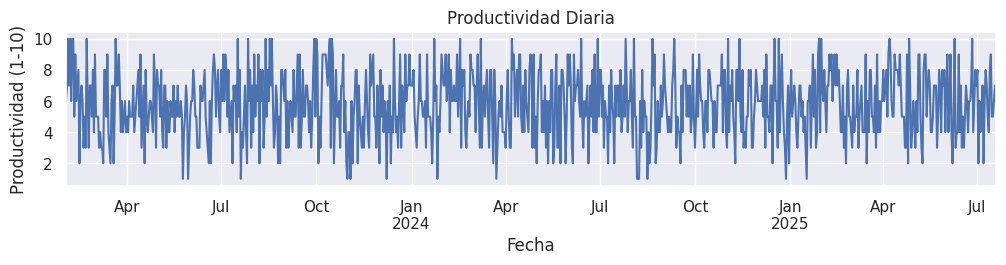

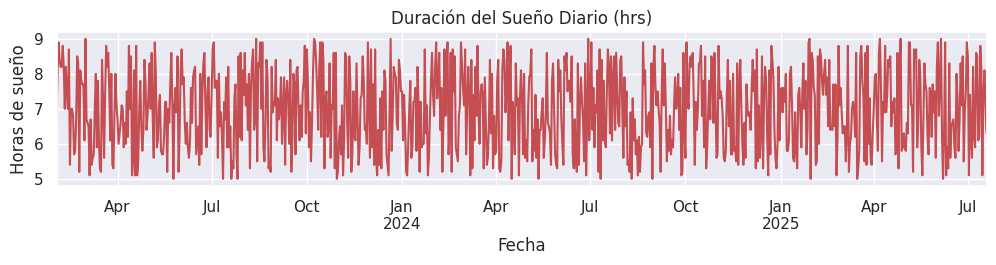

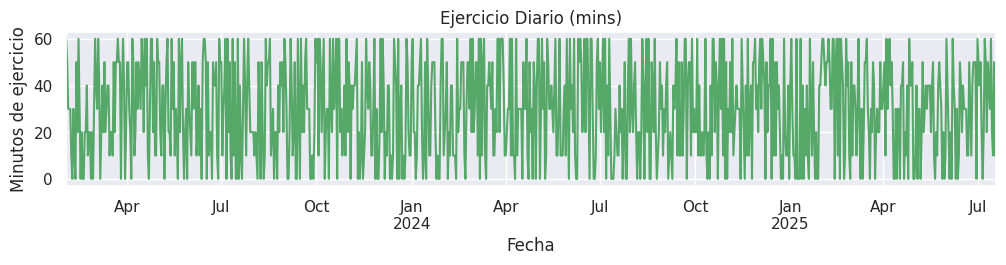

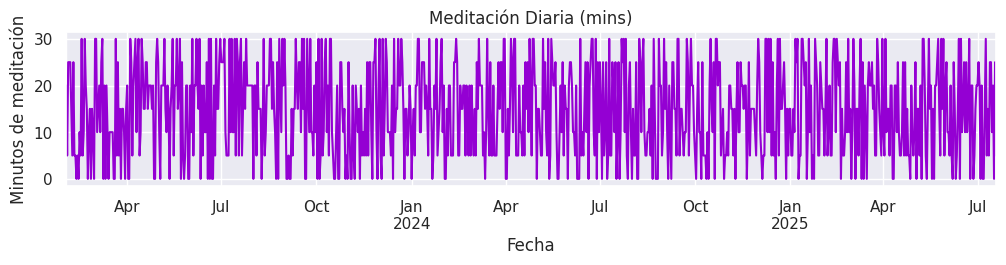

In [ ]:
# Serie de tiempo para la Productividad Diaria
df['Productivity Score (1-10)'].plot(color= 'b', grid=True, figsize=(12, 2))
plt.ylabel('Productividad (1-10)')
plt.xlabel('Fecha')
plt.title('Productividad Diaria')
plt.show()

# Serie de tiempo para la Duración del Sueño Diario
df['Sleep Duration (hrs)'].plot(color= 'r',grid=True, figsize=(12, 2))
plt.ylabel('Horas de sueño')
plt.xlabel('Fecha')
plt.title('Duración del Sueño Diario (hrs)')
plt.show()

# Serie de Tiempo para la duración del Ejercicio
df['Exercise (mins)'].plot(color= 'g',grid=True, figsize=(12, 2))
plt.ylabel('Minutos de ejercicio')
plt.xlabel('Fecha')
plt.title('Ejercicio Diario (mins)')
plt.show()

# Serie de Tiempo para la duración de Meditación
df['Meditation (mins)'].plot(color= 'darkviolet',grid=True, figsize=(12, 2))
plt.ylabel('Minutos de meditación')
plt.xlabel('Fecha')
plt.title('Meditación Diaria (mins)')
plt.show()

▻ **Observaciones:**

* Las series en general se ven ruidosas ya que se están trabajando con datos diarios, por lo tanto se deben usar técnicas de suavizamiento para ver si se pueden identificar patrones a lo largo del tiempo.

* No se logran visualizar patrones estacionales ni un comportamiento que se llegue a repetir, tampoco tendencias claras.

## **Graficas de Series de Tiempo Multivariadas**

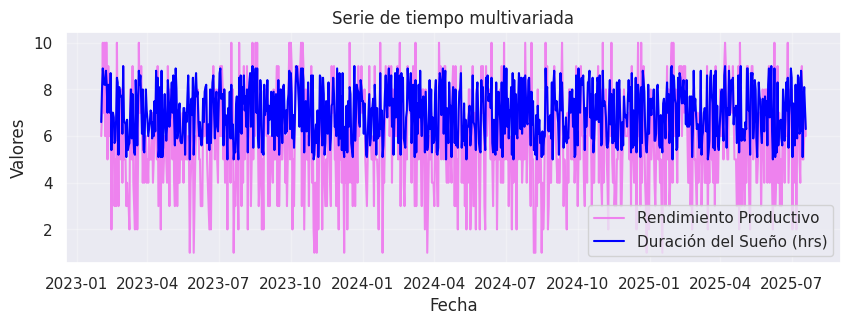

In [ ]:
plt.figure(figsize=(10,3))

plt.plot(df.index, df['Productivity Score (1-10)'], label='Rendimiento Productivo', color='violet')
plt.plot(df.index, df['Sleep Duration (hrs)'], label='Duración del Sueño (hrs)', color='blue')

plt.title("Serie de tiempo multivariada")
plt.xlabel("Fecha")
plt.ylabel("Valores")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

▻ **Observaciones:**

* Se puede visualizar una variabilidad alta en ambas series por lo tanto se encuentran muy ruidosas visualizar patrones de manera más clara.

* En este caso el sueño es mucho más estable que la productividad ya que se nota más regular, se puede concluir que la productividad depende más de otros factores y no solo el sueño.

* No hay tendencias claras, ni tampoco tipos repetitivos.

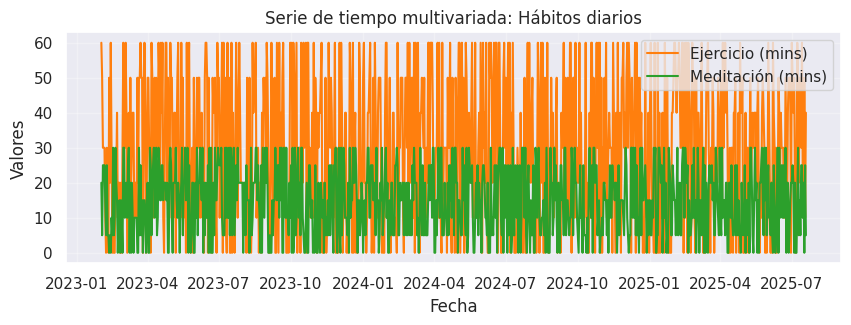

In [ ]:
plt.figure(figsize=(10,3))

plt.plot(df.index, df['Exercise (mins)'], label='Ejercicio (mins)', color='tab:orange')
plt.plot(df.index, df['Meditation (mins)'], label='Meditación (mins)', color='tab:green')

plt.title("Serie de tiempo multivariada: Hábitos diarios")
plt.xlabel("Fecha")
plt.ylabel("Valores")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

▻ **Observaciones**:

* En la figura se observa que las variables de ejercicio y meditación presentan una alta variabilidad a lo largo del tiempo, no se evidencian tendencias claras crecientes o decrecientes.

* Ambas series muestran un comportamiento, con cambios frecuentes entre valores bajos y altos, por lo tanto no se visualiza un patrón sostenido como tal.

* No se identifican ciclos estacionales definidos, ya que no se repite un patrón similar en periodos específicos del tiempo.

* La serie de ejercicio está más por encima en comparación con la de meditación, lo que sugiere una mayor variabilidad en esta actividad.

* Ambas series presentan un comportamiento “ruidoso”, característico de datos registrados a nivel diario.

---

## **Obtencion de Promedios Temporales (Remuestreo)**

In [ ]:
#Serie Mensual

mser = df.resample('ME').mean(numeric_only=True)  #Aqui le indicamos a pandas que ignore las columnas de texto
mser.head()

,Sleep Duration (hrs),Meditation (mins),Exercise (mins),Productivity Score (1-10)
Date,,,,
2023-02-28,7.410714,11.964286,21.785714,6.535714
2023-03-31,6.809677,12.741935,33.548387,5.387097
2023-04-30,6.743333,17.833333,36.333333,5.600000
2023-05-31,6.896774,15.000000,30.322581,5.096774
2023-06-30,7.003333,16.333333,31.333333,5.566667


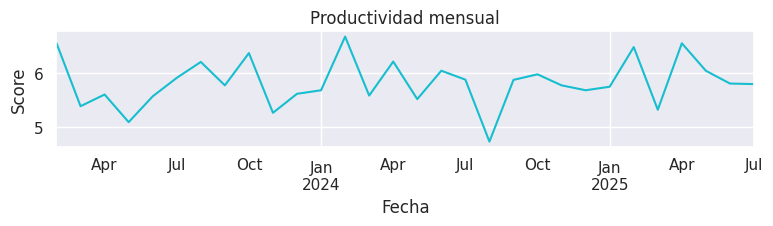

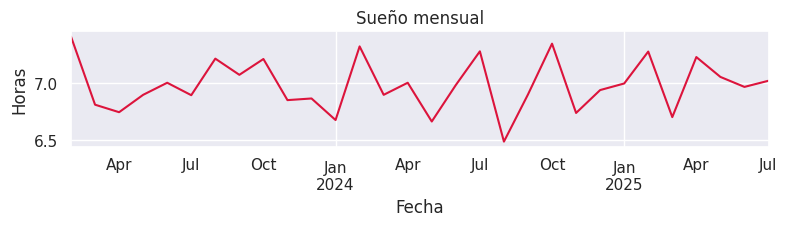

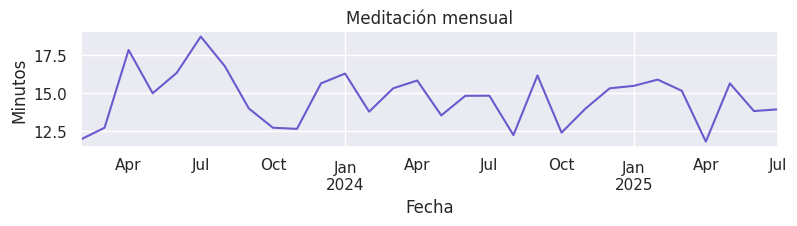

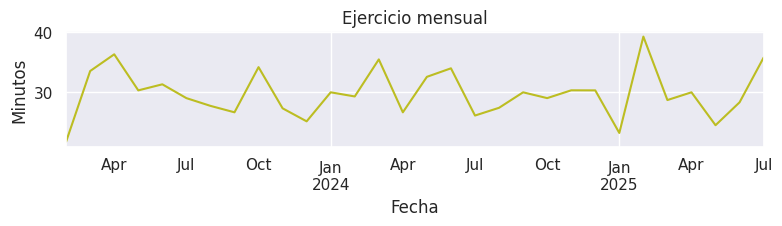

In [ ]:
# Observando las series mensuales

# Productivity
mser['Productivity Score (1-10)'].plot(color='tab:cyan', grid=True, figsize=(9, 1.5))
plt.ylabel('Score')
plt.xlabel('Fecha')
plt.title('Productividad mensual')
plt.show()

# Sleep
mser['Sleep Duration (hrs)'].plot(color='crimson', grid=True, figsize=(9, 1.5))
plt.ylabel('Horas')
plt.xlabel('Fecha')
plt.title('Sueño mensual')
plt.show()

# Meditation
mser['Meditation (mins)'].plot(color='slateblue', grid=True, figsize=(9, 1.5))
plt.ylabel('Minutos')
plt.xlabel('Fecha')
plt.title('Meditación mensual')
plt.show()

# Exercise
mser['Exercise (mins)'].plot(color='tab:olive', grid=True, figsize=(9, 1.5))
plt.ylabel('Minutos')
plt.xlabel('Fecha')
plt.title('Ejercicio mensual')
plt.show()

▻ **Observaciones:**

**Productividad Mensual**:

* En este caso el grafico presenta muchos picos altos y ya después picos muy bajos.

* Se puede observar una caída en agosto, esta caída justamente coincide con la caida en el grafico de sueño mensual. La serie nuevamente vuelve a subir muy alto a partir de enero de 2025, es decir que en esa fecha la serie parece estabilizarse más.

**Sueño Mensual**:

* El año 2024 fue el más inestable para esta variable. El pico máximo de octubre 2024 parece ser un intento de recuperación.

* Termina julio de 2025 en una posición muy equilibrada, justo exactamente sobre las 7 horas.

* Hay muchos picos los cuales evidencian más agotamiento para las personas.

**Meditación Mensual**:

* Aunque ha bajado el tiempo total comparado con 2023, la línea de 2024 y 2025 es mucho más baja, lo que sugiere que el hábito se ha vuelto más constante aunque sea por menos tiempo.

* Hay una caída masiva en en abril de 2025.


**Ejercicio Mensual**:

* En 2025 se registra el pico máximo de toda la serie (casi 40 minutos de promedio). Esto indica un cambio de ritmo o una nueva rutina de entrenamiento muy fuerte a inicios de ese año.

* Al igual que la productividad, el ejercicio cayó mucho en enero de 2025, pero la recuperación fue inmediata.

In [ ]:
#Serie Anual

aser = df.resample('YE').mean(numeric_only=True)
aser.head()

,Sleep Duration (hrs),Meditation (mins),Exercise (mins),Productivity Score (1-10)
Date,,,,
2023-12-31,6.994910,14.97006,29.461078,5.748503
2024-12-31,6.934153,14.54918,30.109290,5.789617
2025-12-31,7.032000,14.57500,29.500000,5.955000


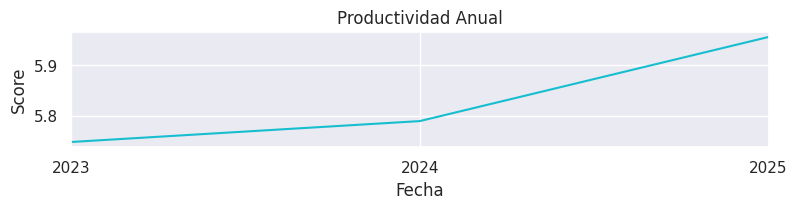

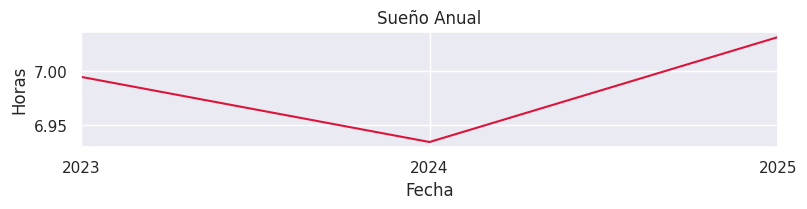

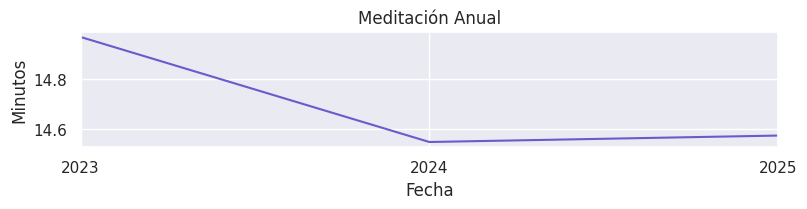

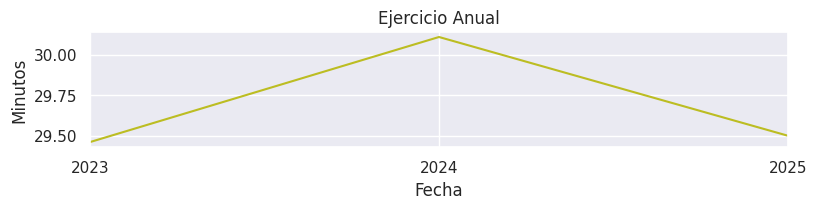

In [ ]:
# Observando las series anuales

# Productivity
aser['Productivity Score (1-10)'].plot(color='tab:cyan', grid=True, figsize=(9, 1.5))
plt.ylabel('Score')
plt.xlabel('Fecha')
plt.title('Productividad Anual')
plt.show()

# Sleep
aser['Sleep Duration (hrs)'].plot(color='crimson', grid=True, figsize=(9, 1.5))
plt.ylabel('Horas')
plt.xlabel('Fecha')
plt.title('Sueño Anual')
plt.show()

# Meditation
aser['Meditation (mins)'].plot(color='slateblue', grid=True, figsize=(9, 1.5))
plt.ylabel('Minutos')
plt.xlabel('Fecha')
plt.title('Meditación Anual')
plt.show()

# Exercise
aser['Exercise (mins)'].plot(color='tab:olive', grid=True, figsize=(9, 1.5))
plt.ylabel('Minutos')
plt.xlabel('Fecha')
plt.title('Ejercicio Anual')
plt.show()

▻ **Observaciones:**

Para las series de tiempo anuales

**Productividad Anual**:

En el gráfico se puede visualizar que presenta un crecimiento progresivo con aceleración positiva. El incremento más significativo ocurre en el periodo 2024-2025, donde el indicador va hasta el máximo.


**Sueño Anual**:

Hubo un descenso en 2024, ya en el año 2025 muestra una recuperación sólida, superando la línea de 2023 y estableciendo un nuevo promedio superior a las 7 horas


**Meditación Anual**:

En la gráfica se puede ver que de 2023 y 2024 hay un descenso notable, ya de 2024 en adelante hacia 2025, se llega a una meditación más constante.


**Ejercicio Anual**:

El año 2024 representó un pico hacía arriba; sin embargo, en 2025 se observa que baja, equilibrandose nuevamente como en 2023.

#**CONSTRUCCIÓN DEL MODELO**

##**Descomposición de la Serie de Tiempo**

En este caso vamos a descomponer y analizar unicamente la serie de productivity Score (1-10) ya que es nuestra variable objetivo esta representa el nivel de rendimiento diario.

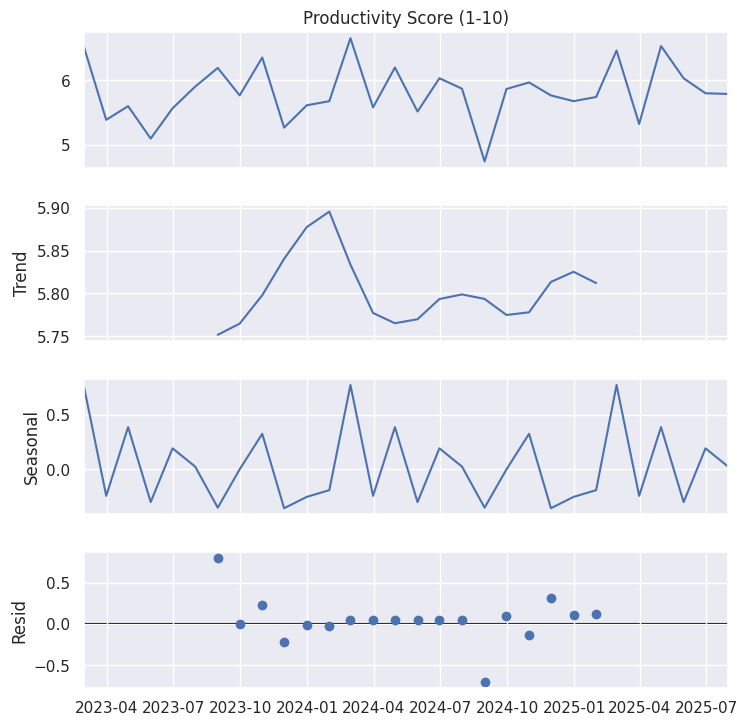

In [ ]:
descomp_prod = tsa.seasonal_decompose(mser['Productivity Score (1-10)'], model='additive')
fig = descomp_prod.plot()
fig.set_size_inches(8, 8)
plt.show()

▻ **Interpretaciones y Observaciones:**


* **Serie original (Productivity Score (1-10)):** Por sí solo, este gráfico es difícil de interpretar debido a la alta variación mensual, no se identifican patrones exactos.

* **Tendencia (Trend):** En este se puede reflejar que del año 2023 al 2024 hay una tendencia hacia arriba positiva, pero esta ya para el mes de julio de 2024 baja en picada o un descenso significativo, por lo tanto algo afectó el rendimiento que llevaba en ese tiempo, para ya después estabilizarse y recuperarse ligeramente para el 2025.

* **Estacionalidad (Seasonal):** En este gráfico se revelan picos muy marcados en periodos especificos. Más que todo a inicios de años o en el primer mes de cada año. Por lo tanto se puede visualizar mejor que la estacionalidad cada año es igual.

* **Residuos (Resid):** Se observa un punto muy bajo cerca de septiembre de 2024 por debajo de cero. Esto nos confirma la presencia de un outlier.

##**Estacionalidad de la Serie**

In [ ]:
# Media movil anual de la serie mensual
anual = mser.rolling(12, center=True).mean()

std = mser.rolling(12).std()

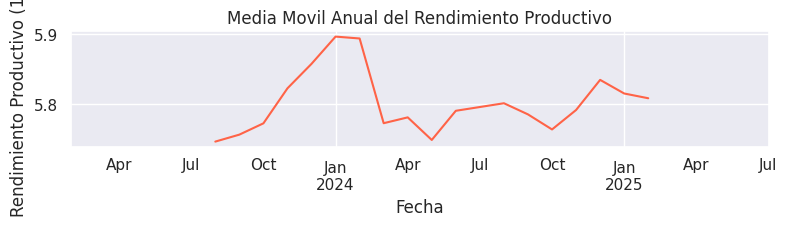

In [ ]:
anual['Productivity Score (1-10)'].plot(color='tomato', grid=True, figsize=(9, 1.5))
plt.ylabel('Rendimiento Productivo (1-10)')
plt.xlabel('Fecha')
plt.title('Media Movil Anual del Rendimiento Productivo')
plt.show()

▻ **Observación:**

**Fase de Crecimiento (2023 - Enero 2024):** Se observa una pendiente ascendente y pronunciada. El rendimiento productivo mejora significativamente durante este periodo, alcanzando su punto máximo histórico a principios de 2024.

**Fase de Descenso (2024):** Inmediatamente después del pico, hay una caída. Esto indica que el nivel de rendimiento alcanzado no fue sostenible en ese momento.

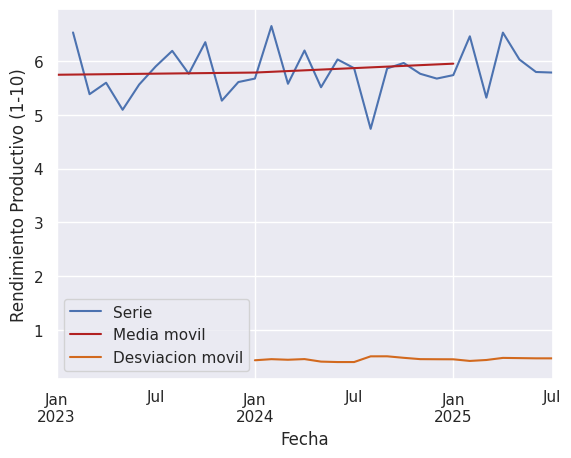

In [ ]:
mser['Productivity Score (1-10)'].plot()
aser['Productivity Score (1-10)'].plot(color='FireBrick')
std['Productivity Score (1-10)'].plot(color='Chocolate')
plt.ylabel('Rendimiento Productivo (1-10)')
plt.xlabel('Fecha')
plt.legend(['Serie', 'Media movil', 'Desviacion movil'])
plt.show()

▻ **Observaciones:**

* **La Media Móvil:** Muestra una tendencia  ascendente. Al no ser una línea totalmente horizontal, la serie tiene una pequeña dependencia del tiempo.

* **La Desviación Móvil:** Se visualiza que la varianza es estacionaria, ya que la línea se mantiene prácticamente horizontal y constante a lo largo del tiempo. Esto indica que la dispersión de los datos no cambia, aunque el promedio sí lo haga.

**PRUEBA ADF**

Para no depender tanto graficamente, podemos probar con la prueba Dickey-Fuller Aumentada. Con esta prueba podemos confirmar si realmente la serie es estacionaria o no es estacionaria


In [ ]:
# prueba adf
adf1, pv1, lags1, obs1, cri1, ib1 = tsa.adfuller (mser['Productivity Score (1-10)'])
print ('Productivity Score (1-10):', pv1)

Productivity Score (1-10): 9.88859409102503e-10


▻ **Observaciones:**

Recordando la interpretación de esta prueba:

* **Hipótesis nula ($H_{0}$):** la serie tiene raíz unitaria; es no estacionaria.
* **Hipótesis alternativa ($H_{1}$):** la serie es estacionaria.

Se decide con el valor-p:

* Si $p < 0.05$ → rechazamos $H_{0}$: la serie es estacionaria.
* Si $p ≥ 0.05$ → no rechazamos $H_{0}$: la serie no es estacionaria.

El resultado de la prueba es un valor-p es muy pequeño y es menor a 0.05. Por lo tanto se concluye que la serie de tiempo **ES ESTACIONARIA**, eso significa que que la media y la varianza son constantes en el tiempo.

##**Determinación de los parámetros del Modelo**

### **Autocorrelación (Correlograma)**

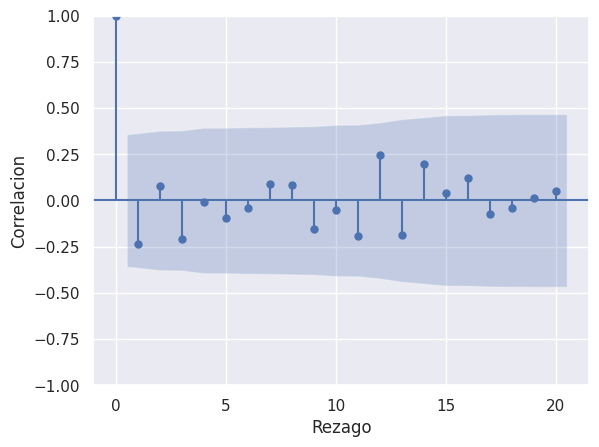

In [ ]:
fig = plot_acf(mser['Productivity Score (1-10)'], lags =20)
plt.xlabel('Rezago')
plt.ylabel('Correlacion')
plt.title('')
plt.show()

▻ **Observación:**

El correlograma muestra que la serie no presenta autocorrelaciones significativas en la mayoría de sus rezagos, ya que los coeficientes se mantienen dentro de los intervalos.

Esto indica que no existe una dependencia temporal marcada entre las observaciones y que el comportamiento de la serie es cercano al de un **ruido blanco**.

Además, no se observa una caída gradual ni patrones persistentes en los primeros rezagos.

#### **Correlograma PACF**

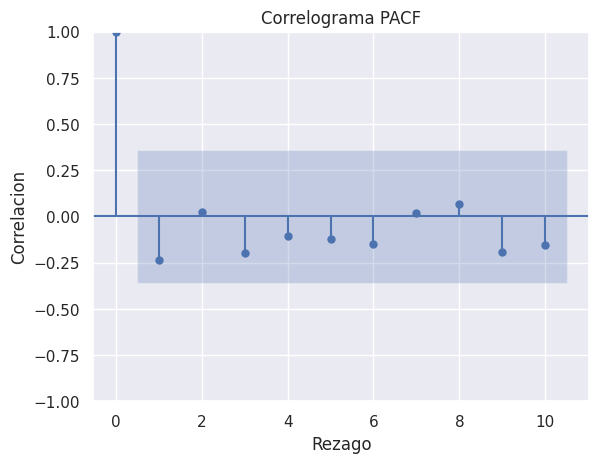

In [ ]:
# Dibujar PACF
fig = plot_pacf(mser['Productivity Score (1-10)'], lags =10)
plt.xlabel('Rezago')
plt.ylabel('Correlacion')
plt.title('Correlograma PACF')
plt.show()

▻ **Observación:**

Este correlograma muestra que, después del rezago 0, los coeficientes de autocorrelación parcial se mantienen dentro de los intervalos, lo que indica que no existen rezagos estadísticamente significativos en la serie.

No se observa un corte claro ni picos relevantes en los primeros rezagos.

En consecuencia, el componente autorregresivo del modelo sería bajo o nulo, sugiriendo inicialmente un valor de **$p = 0$**. Ya que no se evidencia una parte autorregresiva importante.

#### **Diferenciación de una serie para obtener ($d$) tal que sea estacionaria.**

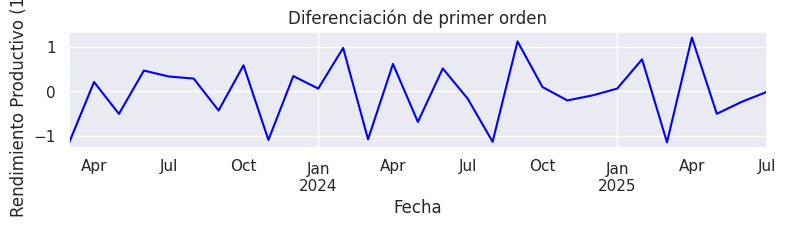

In [ ]:
# diferenciacion de primer orden (quitando nan)
dif_1 = mser.diff().dropna()

dif_1['Productivity Score (1-10)'].plot(color='blue', grid=True, figsize=(9, 1.5))
plt.ylabel('Rendimiento Productivo (1-10)')
plt.xlabel('Fecha')
plt.title('Diferenciación de primer orden')
plt.show()

Para saber si basta con una diferenciación de cierto orden, se deberá realizar la prueba Dickey-Fuller Aumentada (para comprobar estacionariedad). Donde la $H_{0}$ es que la serie tiene una raíz unitaria, lo que, muy simplificado, quiere decir que la serie no es estacionaria.

In [ ]:
adf1, pv1, lags1, obs1, cri1, ib1 = tsa.adfuller(dif_1['Productivity Score (1-10)'])
print ('Productivity Score (1-10)', pv1)

Productivity Score (1-10) 8.049922081067827e-06


▻ **Observación y Analisis:**

Para determinar el orden de diferenciación del modelo ARIMA, se aplicó una diferenciación de primer orden a la serie temporal y posteriormente la prueba Dickey-Fuller Aumentada. Se obtuvo un **p-valor de 0.000008**, inferior al nivel de significancia de 0.05, por lo que se rechaza la hipótesis nula de raíz unitaria.

**En consecuencia, la serie diferenciada es estacionaria, concluyendo que una sola diferenciación es suficiente, por lo tanto se establece $d=1$.**

#### **Correlograma ACF - Obtención de $q$**

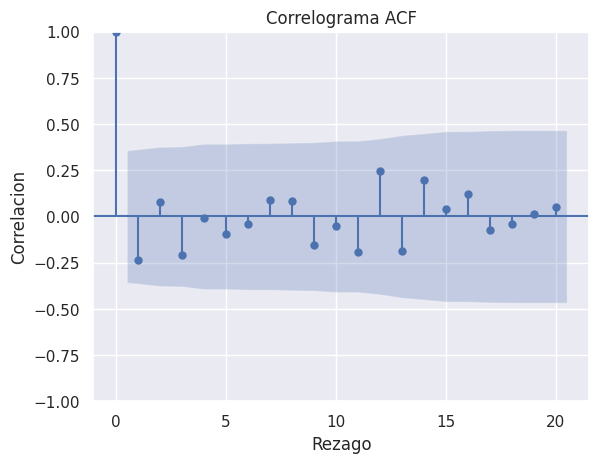

In [ ]:
# Gráfico de Correlograma ACF
fig = plot_acf(mser['Productivity Score (1-10)'], lags = 20)
plt.xlabel('Rezago')
plt.ylabel('Correlacion')
plt.title('Correlograma ACF')
plt.show()

▻ **Observación:**

El correlograma ACF muestra que los coeficientes de autocorrelación en los distintos rezagos permanecen dentro de los intervalos, sin presentar picos estadísticamente significativos ni cortes claros en los primeros rezagos.

Tampoco se observa un patrón de decadencia.

Esto indica ausencia de una estructura de medias móviles relevante en la serie, por lo que inicialmente se sugiere un valor de **$q = 0$**.

* $p = 0$ (según PACF)
* $d = 1$ (según Dickey-Fuller tras primera diferencia)
* $q = 0$ (según ACF)


Teniendo todos estos resultados tenemos la opción de un modelo inicial $ARIMA(0,1,0)$

## **Modelo ARIMA**

$$Y_{t}=c+\phi_{1}Y_{t−1}+\theta_{1}\varepsilon_{t−1}+\varepsilon_{t}$$

In [ ]:
# Obtención del modelo ARIMA
modelo = tsa.ARIMA(mser['Productivity Score (1-10)'], order=(0, 1, 0))

modelo_ajustado = modelo.fit()

print(modelo_ajustado.summary())

                                   SARIMAX Results                                   
Dep. Variable:     Productivity Score (1-10)   No. Observations:                   30
Model:                        ARIMA(0, 1, 0)   Log Likelihood                 -29.876
Date:                       Fri, 17 Apr 2026   AIC                             61.751
Time:                               05:33:22   BIC                             63.119
Sample:                           02-28-2023   HQIC                            62.179
                                - 07-31-2025                                         
Covariance Type:                         opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.4596      0.155      2.963      0.003       0.156       0.764
Ljung-Box (L1) (Q):                  11.13   Jarque-Bera (JB):             

▻ **Observaciones y Analisis:**

El modelo corresponde a un $ARIMA(0,1,0)$, lo que indica que la serie necesitó una diferenciación de primer orden para alcanzar estacionariedad, sin requerir componentes autorregresivos $(p=0)$ ni de medias móviles $(q=0)$.

En este caso, el único parámetro estimado es la varianza del error (0.4596), cuyo valor-p es inferior a 0.05 $(p=0.003)$, por lo que resulta estadísticamente significativo al 95% de confianza. Esto permite concluir que la variabilidad residual del modelo es relevante y distinta de cero.

Por otro lado, los criterios de información obtenidos fueron AIC = 61.751, BIC = 63.119 y HQIC = 62.179. En términos generales, cuanto menores sean estos valores, mejor será el equilibrio entre ajuste y simplicidad del modelo. Por ello, si se estiman otros modelos ARIMA, estos criterios servirán como referencia para seleccionar el más adecuado.

La prueba Ljung-Box presenta un valor-p de 0.00, lo que sugiere evidencia de autocorrelación en los residuos. Esto indica que los errores no se comportan completamente como ruido blanco y que el modelo podría no capturar toda la estructura temporal presente en la serie.

En consecuencia, sería recomendable probar modelos más completos, incorporando términos autorregresivos o de medias móviles.

Adicionalmente, la prueba Jarque-Bera presenta un valor-p de 0.64, superior a 0.05, por lo que no se rechaza la hipótesis de normalidad de los residuos. Esto sugiere que los errores presentan una distribución aproximadamente normal. Asimismo, la prueba de heterocedasticidad arroja un valor-p de 0.93, indicando varianza constante en los residuos.




### **Residuos**

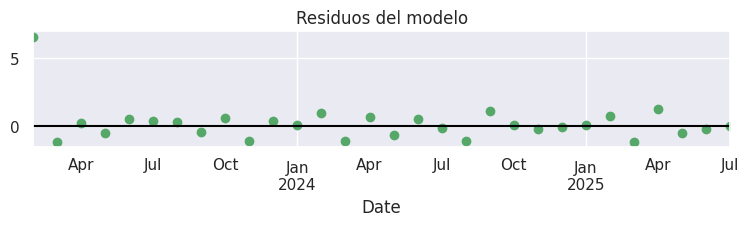

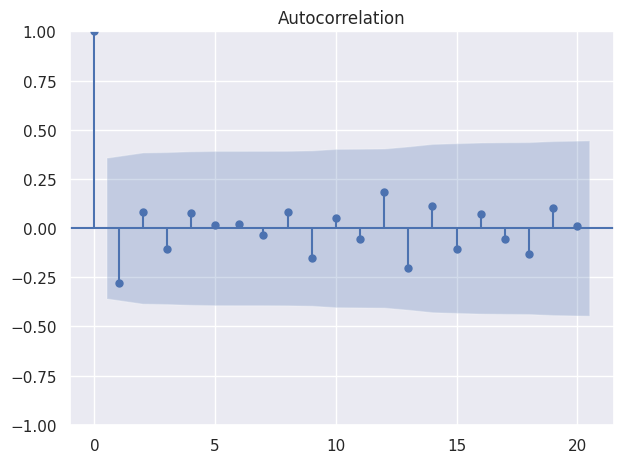

In [ ]:

residuos = modelo_ajustado.resid

residuos.plot(title='Residuos del modelo', style = 'o', color='g', grid=True, figsize=(9, 1.5))
plt.axhline(y=0, color='black', linestyle='-')
plt.show()

plot_acf(residuos, lags=20)
plt.tight_layout()
plt.show()

▻ **Analisis:**

Los residuos se distribuyen alrededor de cero y no presentan una tendencia clara ni un patrón en el tiempo.

Se observa un valor atípico positivo al inicio de la serie, pero después los errores se ponen estables.

En el correlograma, la mayoría de los rezagos se encuentran dentro de los intervalos, por lo que no se evidencia autocorrelación significativa.

En general, los residuos se asemejan a ruido blanco, lo que indica que el modelo captura razonablemente la dinámica de la serie.

### **Ajuste de Preddición del Modelo y Medidas de Desempeño**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

predicciones = modelo_ajustado.fittedvalues

rmse = np.sqrt(mean_squared_error(mser['Productivity Score (1-10)'], predicciones))
mae = mean_absolute_error(mser['Productivity Score (1-10)'], predicciones)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

RMSE: 1.367
MAE: 0.752


▻ **Analisis:**

El modelo presenta un RMSE de 1.367 y un MAE de 0.752. Esto indica que, en promedio, las predicciones se desvían 0.75 unidades respecto a los valores reales, según el error absoluto medio.





###**Modelo Ajustado**

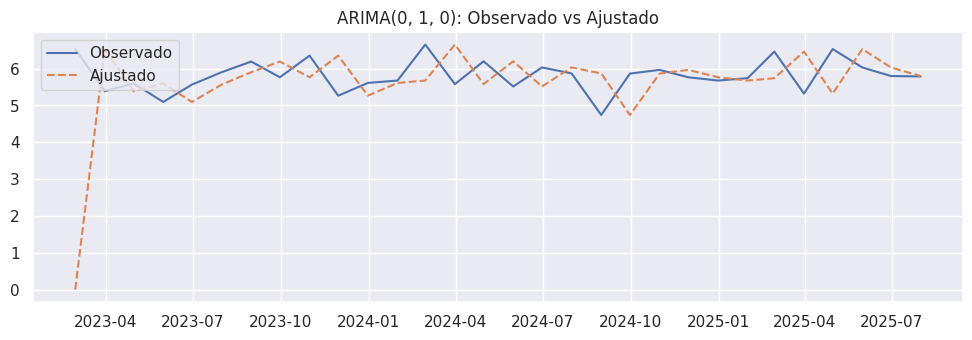

In [ ]:
plt.figure(figsize=(12, 3.5))
plt.plot(mser['Productivity Score (1-10)'], label='Observado')
plt.plot(predicciones, label='Ajustado', linestyle='--')
plt.title('ARIMA(0, 1, 0): Observado vs Ajustado')
plt.legend(loc=2)
plt.show()

▻ **Analisis:**

En la gráfica se observa que la línea ajustada está bastante cerca de la línea observada durante casi todo el periodo, lo que significa que el modelo logra seguir el comportamiento general de la serie. Los valores suben y bajan de forma parecida, por lo que el ajuste es aceptable.

También se nota que en algunos puntos el modelo se aleja un poco de los datos reales, sobre todo cuando hay cambios más rápidos. Al inicio aparece una diferencia grande, algo normal en este tipo de modelos al trabajar con diferenciación.

En general, el modelo ARIMA(0,1,0) representa bien la tendencia general.

## **Ajuste de Predicción del Modelo y Evaluación del Modelo**

In [ ]:
# División de subconjuntos (usaremos los tres primeros años para entrenar y el último para probar)

entrenamiento = mser['Productivity Score (1-10)'].iloc[:-12]
prueba = mser['Productivity Score (1-10)'].iloc[-12:]

print("Entrenamiento:", entrenamiento.index[0], "→", entrenamiento.index[-1])
print("Prueba:", prueba.index[0], "→", prueba.index[-1])

Entrenamiento: 2023-02-28 00:00:00 → 2024-07-31 00:00:00
Prueba: 2024-08-31 00:00:00 → 2025-07-31 00:00:00


In [ ]:
# Entrenamos el modelo
modelo_entrenado = tsa.ARIMA(entrenamiento, order=(0, 1, 0)).fit()

print(modelo_entrenado.summary())

                                   SARIMAX Results                                   
Dep. Variable:     Productivity Score (1-10)   No. Observations:                   18
Model:                        ARIMA(0, 1, 0)   Log Likelihood                 -16.734
Date:                       Fri, 17 Apr 2026   AIC                             35.469
Time:                               05:35:23   BIC                             36.302
Sample:                           02-28-2023   HQIC                            35.551
                                - 07-31-2024                                         
Covariance Type:                         opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.4193      0.198      2.113      0.035       0.030       0.808
Ljung-Box (L1) (Q):                   7.03   Jarque-Bera (JB):             

In [ ]:
# Predichos último año
predichos = modelo_entrenado.get_prediction(36, 47)
predichos.predicted_mean.head(12)

,predicted_mean
2026-02-28,5.870968
2026-03-31,5.870968
2026-04-30,5.870968
2026-05-31,5.870968
2026-06-30,5.870968
2026-07-31,5.870968
2026-08-31,5.870968
2026-09-30,5.870968
2026-10-31,5.870968
2026-11-30,5.870968


Aquí obtenemos las predicciones del modelo entrenado.

In [ ]:
# Comparando estos valores con los observados del último año
print("Observados:",'\n', prueba.head(12), '\n')
print("Predichos:",'\n', predichos.predicted_mean)

Observados: 
 Date
2024-08-31    4.741935
2024-09-30    5.866667
2024-10-31    5.967742
2024-11-30    5.766667
2024-12-31    5.677419
2025-01-31    5.741935
2025-02-28    6.464286
2025-03-31    5.322581
2025-04-30    6.533333
2025-05-31    6.032258
2025-06-30    5.800000
2025-07-31    5.789474
Freq: ME, Name: Productivity Score (1-10), dtype: float64 

Predichos: 
 2026-02-28    5.870968
2026-03-31    5.870968
2026-04-30    5.870968
2026-05-31    5.870968
2026-06-30    5.870968
2026-07-31    5.870968
2026-08-31    5.870968
2026-09-30    5.870968
2026-10-31    5.870968
2026-11-30    5.870968
2026-12-31    5.870968
2027-01-31    5.870968
Freq: ME, Name: predicted_mean, dtype: float64


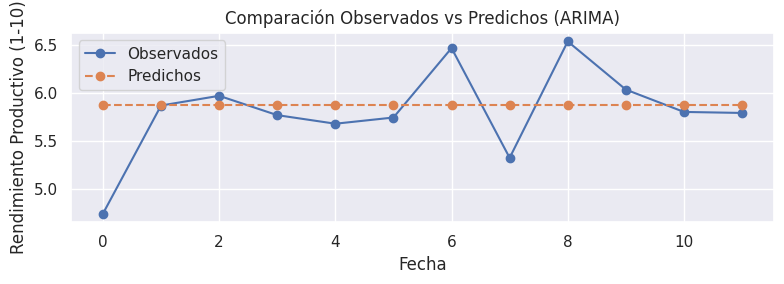

In [ ]:
observados = prueba.values
predichos = predichos.predicted_mean.values
plt.figure(figsize=(8, 3))
plt.plot(observados, marker='o', label="Observados")
plt.plot(predichos, marker='o', label="Predichos", linestyle='--')
plt.title("Comparación Observados vs Predichos (ARIMA)")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento Productivo (1-10)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

▻ **Analisis y Observaciones:**

En la gráfica se observa que los valores predichos se mantienen constantes con un valor de 5.87, mientras que los valores observados presentan pequeñas subidas y bajadas a lo largo del tiempo.

Esto indica que el modelo logra aproximarse al nivel promedio de la serie, pero no alcanza a reflejar las variaciones puntuales de cada periodo.

También se nota que en algunos momentos los valores reales están por encima o por debajo de la predicción, especialmente cuando ocurren picos o variaciones bruscas. Por esta razón, el modelo representa mejor el comportamiento general que los movimientos específicos de la serie.


**Conclusión:** Esto sucede porque el modelo escogido fue un $ARIMA(0,1,0)$, es decir, un modelo sencillo que no tiene parte autorregresiva ni de medias móviles.

Solo trabaja con una diferenciación de primer orden para volver estacionaria la serie.

Por eso, al momento de pronosticar, el modelo toma como referencia el último valor estimado y lo mantiene hacia los siguientes periodos, haciendo que todas las predicciones salgan iguales.

Esto también indica que, al revisar los correlogramas ACF y PACF, no se observaron patrones claros, ni picos significativos, las correlaciones estaban dentro de los limites de confianza en la serie, por lo que no fue necesario utilizar un modelo más complejo